# statistical analysis of inference results

In [1]:
import sys
import os
current_dir = os.path.abspath('')
os.chdir(current_dir)
sys.path.append(os.path.join(current_dir,'..','..','code','BalancingControl'))

import two_stage_utils as tu
import inference_utils as iu
import inference as inf

torch threads 1


/home/sarah/python_venvs/TwoStageStrategies/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Running on device cpu
torch threads 1


In [2]:
import torch
import pyro

import os
from scipy.io import loadmat
import matplotlib.pylab as plt
import seaborn as sns
import pandas as pd
import glob
import pickle as pkl
import json
import gc

from scipy.stats import ttest_1samp
from scipy.stats import pearsonr

### Folder and file settings

In [3]:
results_folder = "results"
inference_folder = os.path.join(results_folder, "inference")
model_comp_folder = os.path.join(results_folder, "model_comparison")

processed_data_folder = "processed_data"

full_data_fname = "full_data.csv"
full_data_file = os.path.join(processed_data_folder, full_data_fname)

mask_file_name = "mask.pkl"
mask_file = os.path.join(processed_data_folder, mask_file_name)

full_data_df = pd.read_csv(full_data_file)

statistics_folder = os.path.join(results_folder, "statistics")

non_fit_fname = "non_fit_file.txt"
non_fit_file = os.path.join(model_comp_folder, non_fit_fname)

scores_file_name = "scores.csv"
scores_file = os.path.join(statistics_folder, scores_file_name)

structured_data_fname = "structured_data.pkl"
structured_data_file = os.path.join(processed_data_folder, structured_data_fname)

n_agents = 206

num_steps = 600

### Experiment parameters

In [4]:
trials =  150#number of trials
T = 3 #number of time steps in each trial
nb = 4 # number of bandits, ie second level rewards
ns = 3+nb #number of states
no = ns #number of observations
na = 2 #number of actions
npi = na**(T-1) #number of policies
nr = 2 #number of rewards
never_reward = ns-nb # states that dont generate rewards

# prob for invalid answer (e.g. no reply). Same frequency as in the real data
# prob for invalid answer (e.g. no reply). Same frequency as in the real data
with open(mask_file, "rb") as f:
    all_mask = pkl.load(f)
# simulations will be done with the same missing actions as in the data.
exp_mask = torch.tensor(all_mask).permute((1,0))
p_valid = exp_mask.sum()/(exp_mask.shape[0]*exp_mask.shape[1])
print(p_valid)

# make global parameter dict:
global_experiment_parameters = {"trials": trials, "T": T, "nb": nb, "ns": ns, "no": no, "na": na, "npi": npi, "nr": nr, "never_reward": never_reward, "p_invalid": p_valid, "mask": exp_mask}

tensor(0.9676)


In [5]:
#generating probability of observations in each state / unity matrix
A = torch.eye(no)


#state transition generative probability (matrix)
B = torch.zeros((ns, ns, na))
b1 = 0.7
nb1 = 1.-b1
b2 = 0.7
nb2 = 1.-b2

B[:,:,0] = torch.tensor([[  0,  0,  0,  0,  0,  0,  0,],
                         [ b1,  0,  0,  0,  0,  0,  0,],
                         [nb1,  0,  0,  0,  0,  0,  0,],
                         [  0,  1,  0,  1,  0,  0,  0,],
                         [  0,  0,  1,  0,  1,  0,  0,],
                         [  0,  0,  0,  0,  0,  1,  0,],
                         [  0,  0,  0,  0,  0,  0,  1,],])

B[:,:,1] = torch.tensor([[  0,  0,  0,  0,  0,  0,  0,],
                         [nb2,  0,  0,  0,  0,  0,  0,],
                         [ b2,  0,  0,  0,  0,  0,  0,],
                         [  0,  0,  0,  1,  0,  0,  0,],
                         [  0,  0,  0,  0,  1,  0,  0,],
                         [  0,  1,  0,  0,  0,  1,  0,],
                         [  0,  0,  1,  0,  0,  0,  1,],])

# add to parameter dict
global_experiment_parameters["A"] = A
global_experiment_parameters["B"] = B

In [6]:
with open(structured_data_file, "rb") as f:
    data = pkl.load(f)

for key in data.keys():
    data[key] = torch.from_numpy(data[key])

# print(data)

### Convenience functions

In [7]:
def load_BCC_results(learn_rewards, learn_habit, learn_cached, use_h, base_dir, global_experiment_parameters, valid, fname_base, num_steps, data, param_names):    

    # set up agent
    bayes_agent = tu.set_up_Bayesian_inference_agent(n_agents, learn_rewards, learn_habit, learn_cached, base_dir, 
                                                    global_experiment_parameters, data["valid"], remove_old=False, 
                                                    use_h=use_h)

    print('analyzing '+str(n_agents)+' data sets')

    resample = False

    # set up inference
    inferrer = inf.GeneralGroupInference(bayes_agent, data)

    fname_str = fname_base + str(num_steps)+'_'+str(n_agents)+'agents'

    inferrer.load_parameters(os.path.join(base_dir, fname_str+"_parameter.save"))

    inferrer.load_elbo(os.path.join(base_dir, fname_str+"_elbo.save"))

    if resample:
        mean_df, sample_df, locs_df = iu.sample_posterior(inferrer, param_names, fname_str, base_dir) 
    else:
        mean_df, sample_df, locs_df = iu.load_samples(base_dir, fname_str) 

    return mean_df, sample_df, locs_df

In [8]:
def load_MFMB_results(learn_prior, use_orig, use_p, restrict_alpha, min_alpha, max_dt, base_dir, global_experiment_parameters, valid, fname_base, num_steps, data, param_names):    

    # set up agent
    mfmb_agent = tu.set_up_mbmf_inference_agent(n_agents, learn_prior, use_orig, use_p, restrict_alpha, max_dt, min_alpha, base_dir, global_experiment_parameters, valid, remove_old=False)

    print('analyzing '+str(n_agents)+' data sets')

    resample = False

    # set up inference
    inferrer = inf.GeneralGroupInference(mfmb_agent, data)

    fname_str = fname_base + str(num_steps)+'_'+str(n_agents)+'agents'

    inferrer.load_parameters(os.path.join(base_dir, fname_str+"_parameter.save"))

    inferrer.load_elbo(os.path.join(base_dir, fname_str+"_elbo.save"))

    if resample:
        mean_df, sample_df, locs_df = iu.sample_posterior(inferrer, param_names, fname_str, base_dir) 
    else:
        mean_df, sample_df, locs_df = iu.load_samples(base_dir, fname_str) 

    return mean_df, sample_df, locs_df

### load behavioral outputs of participants: mf-/mb-scores

In [9]:
scores_df = pd.read_csv(scores_file)

# Define agents and load results

## BCC2 planning agent

In [10]:
# load BCC2 data

# set parameters and their names

learn_rewards = True
learn_habit = False
use_h = False
learn_cached = False

param_names = []
param_ranges = []

prefix = "BCC"
model_name = "Bayesian prior-based contextual control model"
n_pars = 0
agnt_str = ""

if learn_rewards:
    n_pars += 2
    param_names += ["dec temp", "reward rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_planning"

if learn_habit:
    # infer_h = True
    # infer_policy_rate = True 
    n_pars += 2
    agnt_str += "_repetition"
    param_names += ["habitual tendency", "policy rate"]
    if use_h:
        agnt_str += "_h"
        param_ranges += [[0,1], [0,1]]
    else:
        agnt_str += "_weight"
        param_ranges += [[0,8], [0,1]]
# else:
#     infer_h = False
#     infer_policy_rate = False

if learn_cached:
    n_pars += 2
    param_names += ["cached weight", "cached rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_cached"

assert n_pars > 0, "please turn any part of the agent on, it cannot run without any learning or inference."

# prepare for saving results
# make base filename and folder string
BCC2_p_agent_type = prefix+"_"+str(n_pars)+"pars"+agnt_str
print(BCC2_p_agent_type)

BCC2_p_agent_params = {"learn_rewards": learn_rewards, "learn_habit": learn_habit, 
                       "learn_cached": learn_cached, "use_h": use_h,
                       "param_names": param_names, "param_ranges": param_ranges}

BCC_2pars_planning


BCC_2pars_planning_inference_
2
analyzing 206 data sets


/home/sarah/src/TwoStageStrategies/Kool_et_al_data/daw_paradigm/../../code/BalancingControl/perception.py:142: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3683.)
  self.big_trans_matrix = ar.stack([ar.stack([generative_model_states[:,:,policies[pi,t]] for pi in range(self.npi)]) for t in range(self.T-1)]).T.to(device)
/home/sarah/python_venvs/TwoStageStrategies/lib/python3.13/site-packages/pyro/params/param_store.py:334: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://git

<Figure size 640x480 with 0 Axes>

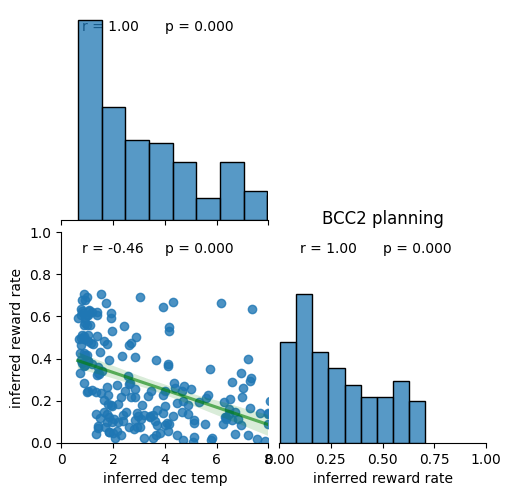

In [11]:
BCC2_p_fname_base = BCC2_p_agent_type+"_inference_"
print(BCC2_p_fname_base)
# define folder where we want to save data
BCC2_p_base_dir = os.path.join(inference_folder,BCC2_p_fname_base[:-1])

BCC2_p_mean_df, BCC2_p_sample_df, BCC2_p_locs_df = \
    load_BCC_results(BCC2_p_agent_params["learn_rewards"], BCC2_p_agent_params["learn_habit"], 
                     BCC2_p_agent_params["learn_cached"], BCC2_p_agent_params["use_h"],
                     BCC2_p_base_dir, global_experiment_parameters, exp_mask, BCC2_p_fname_base, 
                     num_steps, data, BCC2_p_agent_params["param_names"])

plt.figure()
vars_of_interest = ["inferred "+name for name in param_names]
f = sns.pairplot(data=BCC2_p_mean_df, kind='reg', diag_kind="hist", corner=True,
                    plot_kws={'line_kws': {'color': 'green', 'alpha': 0.6}},
                    x_vars=vars_of_interest, y_vars=vars_of_interest)
f.map(tu.annot_corrfunc)
for p, p_range in enumerate(param_ranges):
    f.axes[1,p].set_xlim(p_range)
    f.axes[p,0].set_ylim(p_range)
plt.title("BCC2 planning")
#plt.savefig(os.path.join(base_dir, fname_str+"_pairplot_means_inferred_corr.svg"))
plt.show()

## BCC4 planning repetition agent

In [12]:
# BCC4_planning_repetition agent

learn_rewards = True
learn_habit = True
use_h = False
learn_cached = False

param_names = []
param_ranges = []

prefix = "BCC"
model_name = "Bayesian prior-based contextual control model"
n_pars = 0
agnt_str = ""

if learn_rewards:
    n_pars += 2
    param_names += ["dec temp", "reward rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_planning"

if learn_habit:
    # infer_h = True
    # infer_policy_rate = True 
    n_pars += 2
    agnt_str += "_repetition"
    param_names += ["habitual tendency", "policy rate"]
    if use_h:
        agnt_str += "_h"
        param_ranges += [[0,1], [0,1]]
    else:
        agnt_str += "_weight"
        param_ranges += [[0,8], [0,1]]
# else:
#     infer_h = False
#     infer_policy_rate = False

if learn_cached:
    n_pars += 2
    param_names += ["cached weight", "cached rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_cached"

assert n_pars > 0, "please turn any part of the agent on, it cannot run without any learning or inference."

# prepare for saving results
# make base filename and folder string
BCC4_p_r_agent_type = prefix+"_"+str(n_pars)+"pars"+agnt_str
print(BCC4_p_r_agent_type)

BCC4_p_r_agent_params = {"learn_rewards": learn_rewards, "learn_habit": learn_habit, 
                       "learn_cached": learn_cached, "use_h": use_h,
                       "param_names": param_names, "param_ranges": param_ranges}

BCC_4pars_planning_repetition_weight


BCC_4pars_planning_repetition_weight_inference_
4
analyzing 206 data sets


/home/sarah/python_venvs/TwoStageStrategies/lib/python3.13/site-packages/pyro/params/param_store.py:334: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(inp

<Figure size 640x480 with 0 Axes>

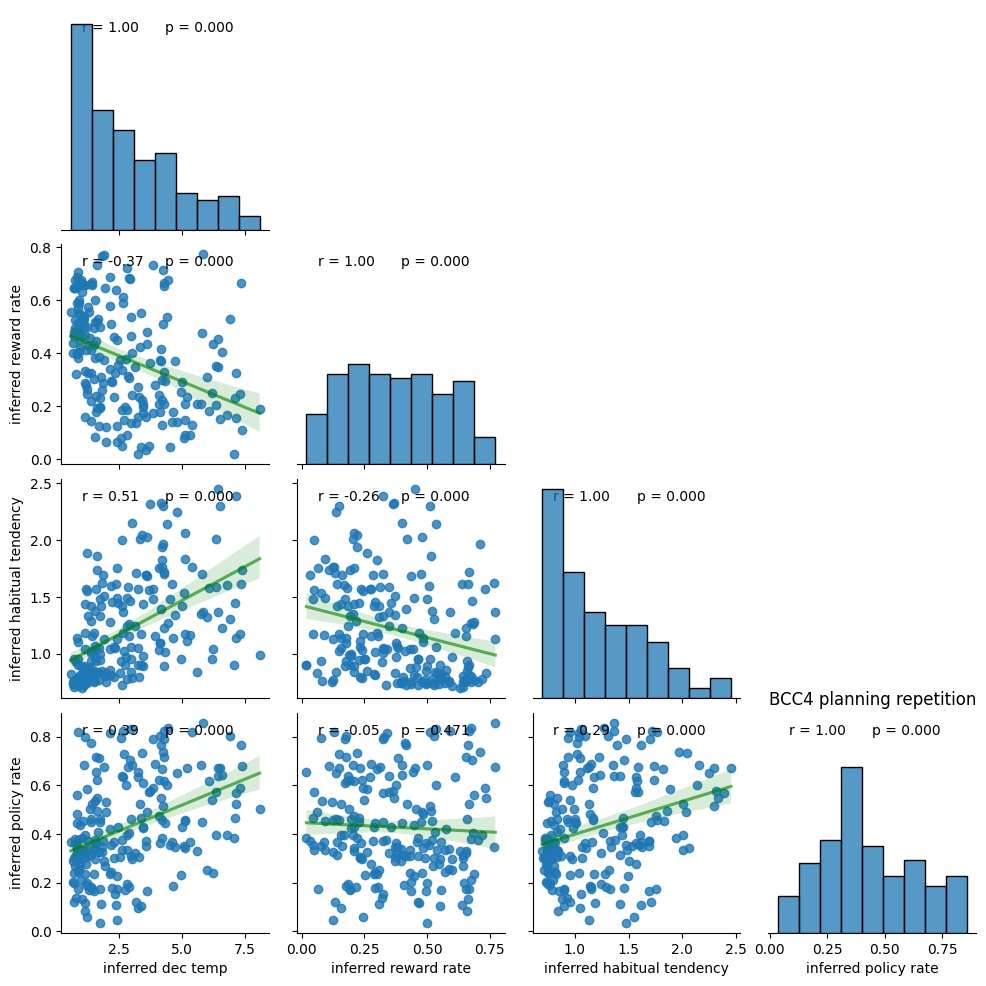

In [13]:
BCC4_p_r_fname_base = BCC4_p_r_agent_type+"_inference_"
print(BCC4_p_r_fname_base)
# define folder where we want to save data
BCC4_p_r_base_dir = os.path.join(inference_folder,BCC4_p_r_fname_base[:-1])

BCC4_p_r_mean_df, BCC4_p_r_sample_df, BCC4_p_r_locs_df = \
    load_BCC_results(BCC4_p_r_agent_params["learn_rewards"], BCC4_p_r_agent_params["learn_habit"], 
                     BCC4_p_r_agent_params["learn_cached"], BCC4_p_r_agent_params["use_h"],
                     BCC4_p_r_base_dir, global_experiment_parameters, exp_mask, BCC4_p_r_fname_base, 
                     num_steps, data, BCC4_p_r_agent_params["param_names"])

plt.figure()
vars_of_interest = ["inferred "+name for name in param_names]
f = sns.pairplot(data=BCC4_p_r_mean_df, kind='reg', diag_kind="hist", corner=True,
                    plot_kws={'line_kws': {'color': 'green', 'alpha': 0.6}},
                    x_vars=vars_of_interest, y_vars=vars_of_interest)
f.map(tu.annot_corrfunc)
# for p, p_range in enumerate(param_ranges):
#     f.axes[1,p].set_xlim(p_range)
#     f.axes[p,0].set_ylim(p_range)
plt.title("BCC4 planning repetition")
#plt.savefig(os.path.join(base_dir, fname_str+"_pairplot_means_inferred_corr.svg"))
plt.show()

## BCC4 planning cached agent

In [14]:
# BCC4_planning_cached agent

learn_rewards = True
learn_habit = False
use_h = False
learn_cached = True

param_names = []
param_ranges = []

prefix = "BCC"
model_name = "Bayesian prior-based contextual control model"
n_pars = 0
agnt_str = ""

if learn_rewards:
    n_pars += 2
    param_names += ["dec temp", "reward rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_planning"

if learn_habit:
    # infer_h = True
    # infer_policy_rate = True 
    n_pars += 2
    agnt_str += "_repetition"
    param_names += ["habitual tendency", "policy rate"]
    if use_h:
        agnt_str += "_h"
        param_ranges += [[0,1], [0,1]]
    else:
        agnt_str += "_weight"
        param_ranges += [[0,8], [0,1]]
# else:
#     infer_h = False
#     infer_policy_rate = False

if learn_cached:
    n_pars += 2
    param_names += ["cached weight", "cached rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_cached"

assert n_pars > 0, "please turn any part of the agent on, it cannot run without any learning or inference."

# prepare for saving results
# make base filename and folder string
BCC4_p_c_agent_type = prefix+"_"+str(n_pars)+"pars"+agnt_str
print(BCC4_p_c_agent_type)

BCC4_p_c_agent_params = {"learn_rewards": learn_rewards, "learn_habit": learn_habit, 
                       "learn_cached": learn_cached, "use_h": use_h,
                       "param_names": param_names, "param_ranges": param_ranges}

BCC_4pars_planning_cached


BCC_4pars_planning_cached_inference_
4
analyzing 206 data sets


/home/sarah/python_venvs/TwoStageStrategies/lib/python3.13/site-packages/pyro/params/param_store.py:334: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(inp

<Figure size 640x480 with 0 Axes>

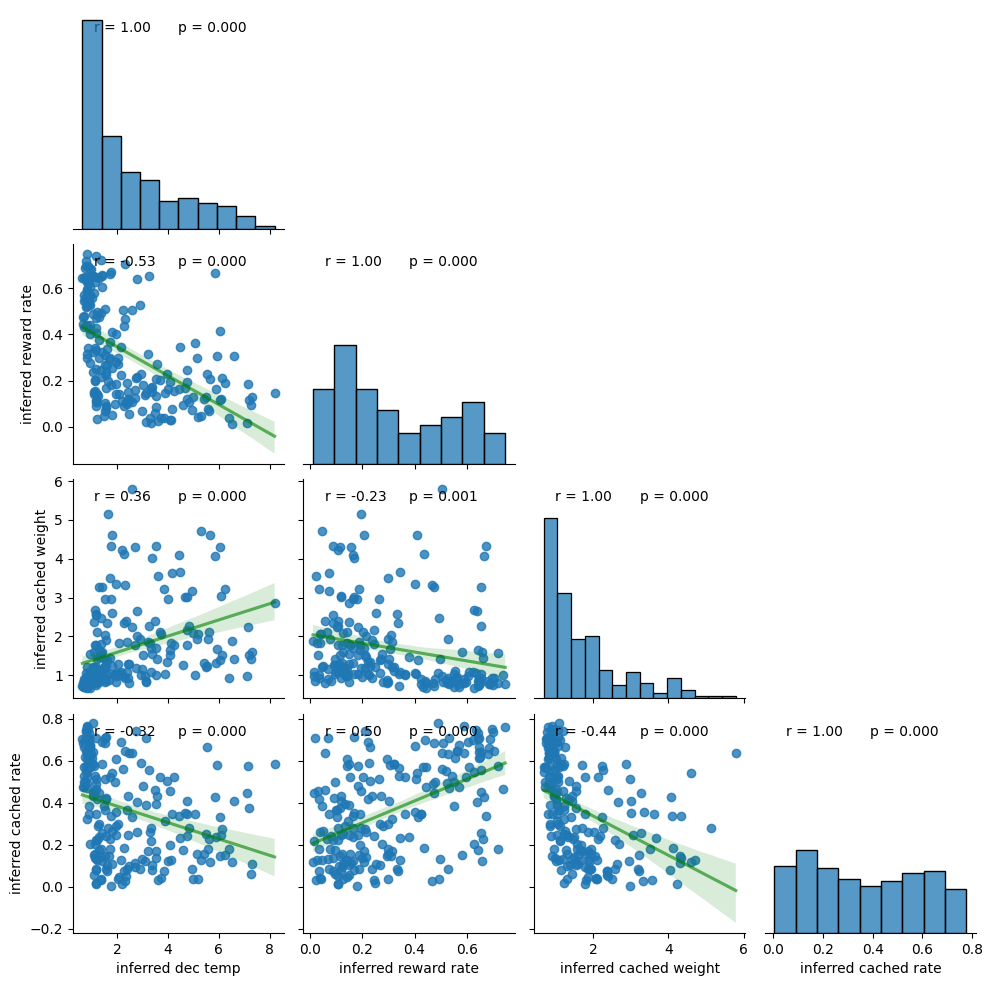

In [15]:
BCC4_p_c_fname_base = BCC4_p_c_agent_type+"_inference_"
print(BCC4_p_c_fname_base)
# define folder where we want to save data
BCC4_p_c_base_dir = os.path.join(inference_folder,BCC4_p_c_fname_base[:-1])

BCC4_p_c_mean_df, BCC4_p_c_sample_df, BCC4_p_c_locs_df = \
    load_BCC_results(BCC4_p_c_agent_params["learn_rewards"], BCC4_p_c_agent_params["learn_habit"], 
                     BCC4_p_c_agent_params["learn_cached"], BCC4_p_c_agent_params["use_h"],
                     BCC4_p_c_base_dir, global_experiment_parameters, exp_mask, BCC4_p_c_fname_base, 
                     num_steps, data, BCC4_p_c_agent_params["param_names"])

plt.figure()
vars_of_interest = ["inferred "+name for name in param_names]
f = sns.pairplot(data=BCC4_p_c_mean_df, kind='reg', diag_kind="hist", corner=True,
                    plot_kws={'line_kws': {'color': 'green', 'alpha': 0.6}},
                    x_vars=vars_of_interest, y_vars=vars_of_interest)
f.map(tu.annot_corrfunc)
# for p, p_range in enumerate(param_ranges):
#     f.axes[2,p].set_xlim(p_range)
#     f.axes[p,0].set_ylim(p_range)
# plt.title("BCC4 planning cached")
#plt.savefig(os.path.join(base_dir, fname_str+"_pairplot_means_inferred_corr.svg"))
plt.show()

## BCC6 planning repetition cached agent

In [16]:
# BCC4_planning_cached agent

learn_rewards = True
learn_habit = True
use_h = False
learn_cached = True

param_names = []
param_ranges = []

prefix = "BCC"
model_name = "Bayesian prior-based contextual control model"
n_pars = 0
agnt_str = ""

if learn_rewards:
    n_pars += 2
    param_names += ["dec temp", "reward rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_planning"

if learn_habit:
    # infer_h = True
    # infer_policy_rate = True 
    n_pars += 2
    agnt_str += "_repetition"
    param_names += ["habitual tendency", "policy rate"]
    if use_h:
        agnt_str += "_h"
        param_ranges += [[0,1], [0,1]]
    else:
        agnt_str += "_weight"
        param_ranges += [[0,8], [0,1]]
# else:
#     infer_h = False
#     infer_policy_rate = False

if learn_cached:
    n_pars += 2
    param_names += ["cached weight", "cached rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_cached"

assert n_pars > 0, "please turn any part of the agent on, it cannot run without any learning or inference."

# prepare for saving results
# make base filename and folder string
BCC6_p_r_c_agent_type = prefix+"_"+str(n_pars)+"pars"+agnt_str
print(BCC6_p_r_c_agent_type)

BCC6_p_r_c_agent_params = {"learn_rewards": learn_rewards, "learn_habit": learn_habit, 
                       "learn_cached": learn_cached, "use_h": use_h,
                       "param_names": param_names, "param_ranges": param_ranges}

BCC_6pars_planning_repetition_weight_cached


BCC_6pars_planning_repetition_weight_cached_inference_
6
analyzing 206 data sets


/home/sarah/python_venvs/TwoStageStrategies/lib/python3.13/site-packages/pyro/params/param_store.py:334: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(inp

<Figure size 640x480 with 0 Axes>

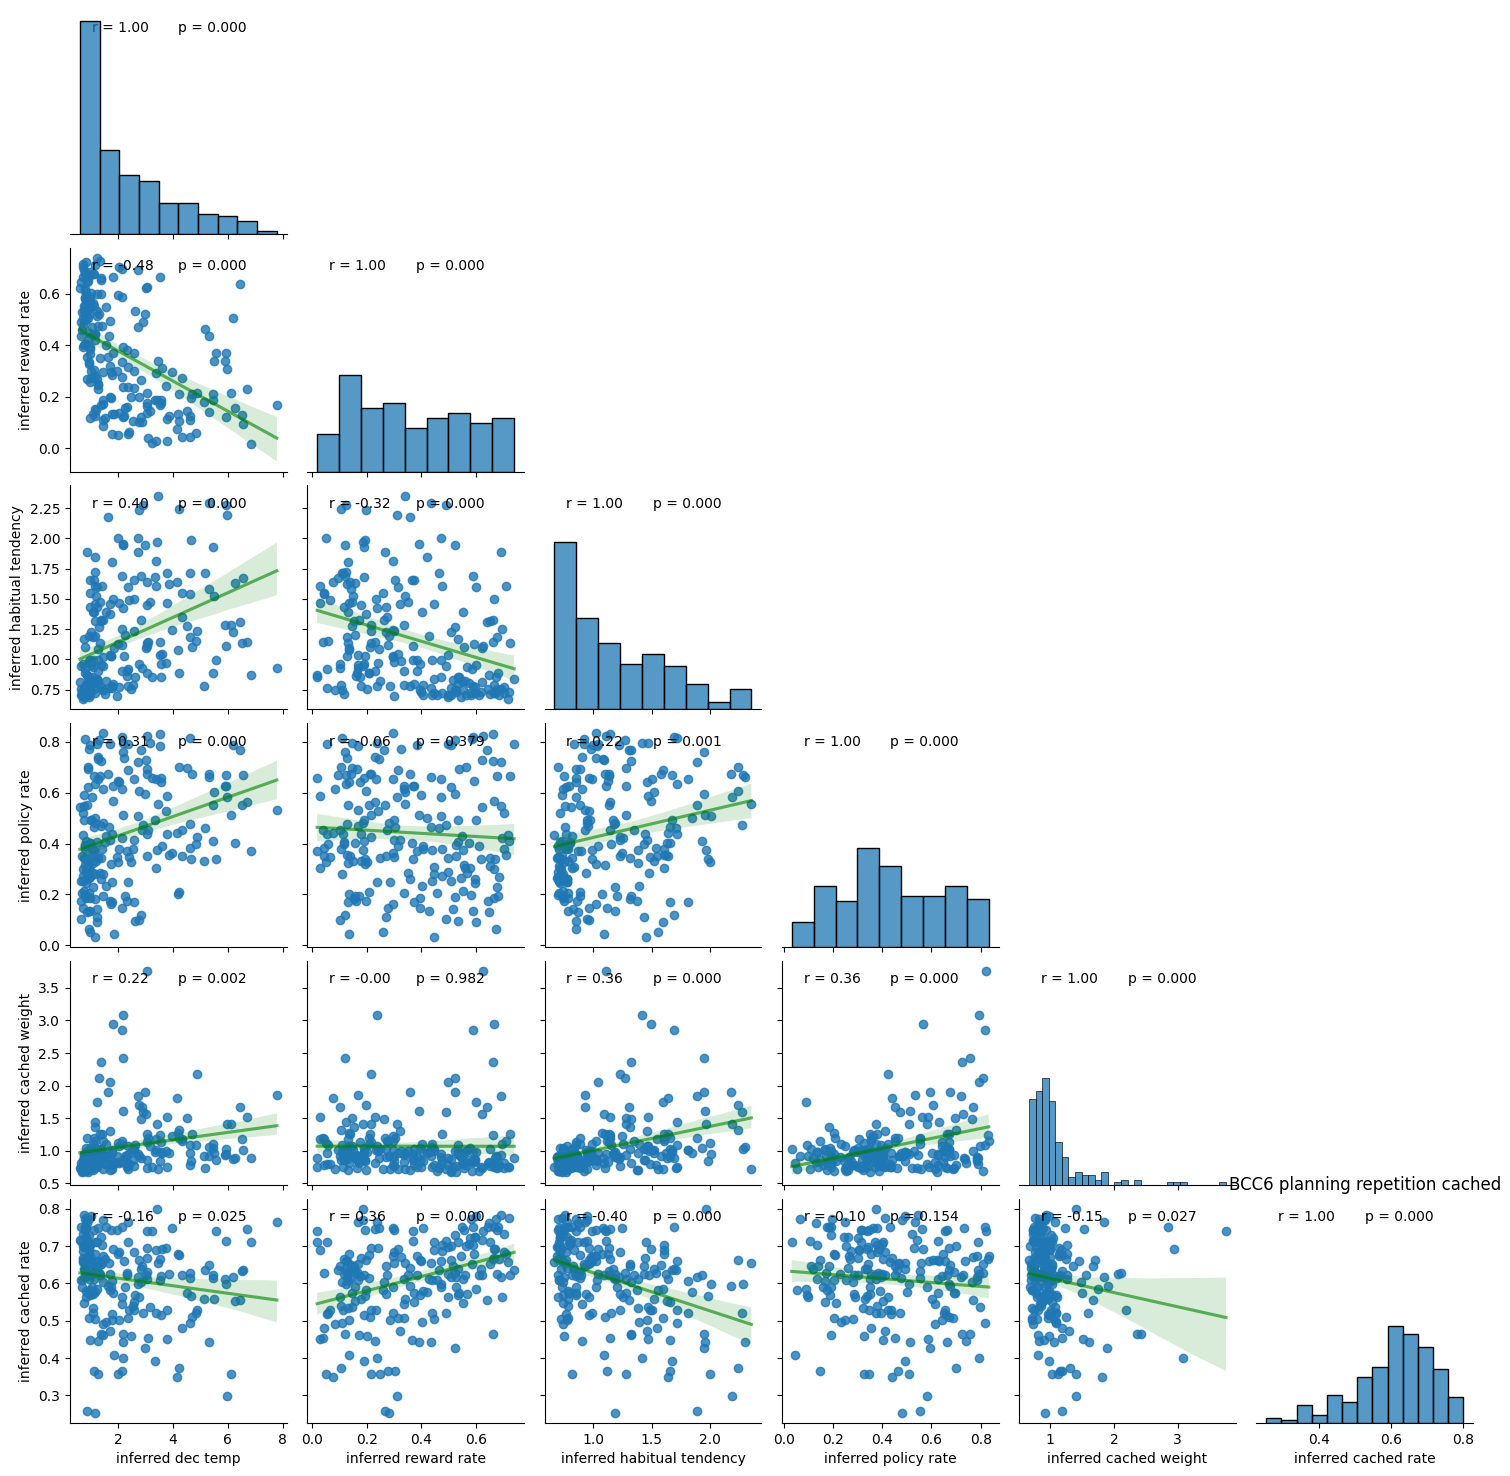

In [17]:
BCC6_p_r_c_fname_base = BCC6_p_r_c_agent_type+"_inference_"
print(BCC6_p_r_c_fname_base)
# define folder where we want to save data
BCC6_p_r_c_base_dir = os.path.join(inference_folder,BCC6_p_r_c_fname_base[:-1])

BCC6_p_r_c_mean_df, BCC6_p_r_c_sample_df, BCC6_p_r_c_locs_df = \
    load_BCC_results(BCC6_p_r_c_agent_params["learn_rewards"], BCC6_p_r_c_agent_params["learn_habit"], 
                     BCC6_p_r_c_agent_params["learn_cached"], BCC6_p_r_c_agent_params["use_h"],
                     BCC6_p_r_c_base_dir, global_experiment_parameters, exp_mask, BCC6_p_r_c_fname_base, 
                     num_steps, data, BCC6_p_r_c_agent_params["param_names"])

plt.figure()
vars_of_interest = ["inferred "+name for name in param_names]
f = sns.pairplot(data=BCC6_p_r_c_mean_df, kind='reg', diag_kind="hist", corner=True,
                    plot_kws={'line_kws': {'color': 'green', 'alpha': 0.6}},
                    x_vars=vars_of_interest, y_vars=vars_of_interest)
f.map(tu.annot_corrfunc)
# for p, p_range in enumerate(param_ranges):
#     f.axes[2,p].set_xlim(p_range)
#     f.axes[p,0].set_ylim(p_range)
plt.title("BCC6 planning repetition cached")
#plt.savefig(os.path.join(base_dir, fname_str+"_pairplot_means_inferred_corr.svg"))
plt.show()

## MFMB4 MF MB agent

In [18]:
# MFMB4 analysis

# set parameters and their names

learn_prior = False

use_orig = True

use_p = False
restrict_alpha = False
max_dt = 6

n_pars = 4

prefix = "MFMB"
agnt_str = ""

if use_orig:
    agnt_str += "_mf_mb_Orig"
    param_names = ["discount", "learning rate", "dec temp", "weight"]
    model_name = "original original w and beta model"
    param_ranges = [[0,1], [0,1], [0,8], [0,1]]
else:
    agnt_str += "_mf_mb"
    param_names = ["mb weight", "discount", "mf weight", "learning rate"]
    model_name = "two beta mbmf model"
    param_ranges = [[0,max_dt], [0,1], [0,max_dt], [0,1]]


if learn_prior:
    n_pars += 2
    param_names += ["prior lr", "prior weight"]
    param_ranges += [[0,1], [0,max_dt]]
    agnt_str += "_prior"

if use_p:
    n_pars += 1
    agnt_str += "_p"
    param_names += ["repetition"]
    
if restrict_alpha:
    agnt_str += "_resticted"
    min_alpha = 0.1
else:
    min_alpha = 0

max_dt = 6

# prepare for saving results
# make base filename and folder string
MFMB4_mf_mb_agent_type = prefix+"_"+str(n_pars)+"pars"+agnt_str

MFMB4_mf_mb_agent_params = {"learn_prior": learn_prior, "use_p": use_p, "use_orig": use_orig, 
                            "restrict_alpha": restrict_alpha, "max_dt": max_dt, "min_alpha": min_alpha,
                            "param_names": param_names, "param_ranges": param_ranges}


MFMB_4pars_mf_mb_Orig_inference_
analyzing 206 data sets


/home/sarah/python_venvs/TwoStageStrategies/lib/python3.13/site-packages/pyro/params/param_store.py:334: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(inp

<Figure size 640x480 with 0 Axes>

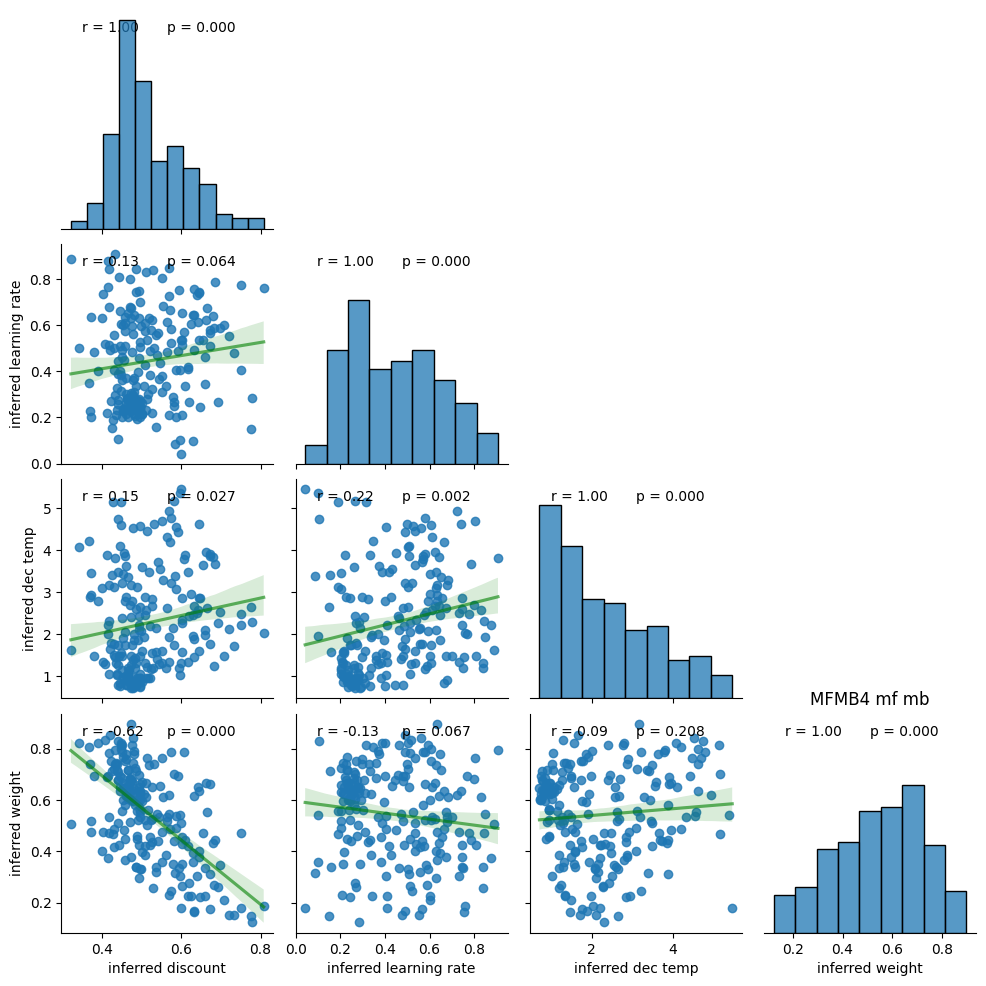

In [19]:
MFMB4_mf_mb_fname_base = MFMB4_mf_mb_agent_type+"_inference_"
print(MFMB4_mf_mb_fname_base)
# define folder where we want to save data
MFMB4_mf_mb_base_dir = os.path.join(inference_folder,MFMB4_mf_mb_fname_base[:-1])

MFMB4_mf_mb_mean_df, MFMB4_mf_mb_sample_df, MFMB4_mf_mb_locs_df = \
    load_MFMB_results(MFMB4_mf_mb_agent_params["learn_prior"], MFMB4_mf_mb_agent_params["use_orig"], 
                      MFMB4_mf_mb_agent_params["use_p"], MFMB4_mf_mb_agent_params["restrict_alpha"], 
                      MFMB4_mf_mb_agent_params["min_alpha"], MFMB4_mf_mb_agent_params["max_dt"], 
                      MFMB4_mf_mb_base_dir, global_experiment_parameters, data["valid"], 
                      MFMB4_mf_mb_fname_base, num_steps, 
                      data, MFMB4_mf_mb_agent_params["param_names"])

plt.figure()
vars_of_interest = ["inferred "+name for name in param_names]
f = sns.pairplot(data=MFMB4_mf_mb_mean_df, kind='reg', diag_kind="hist", corner=True,
                    plot_kws={'line_kws': {'color': 'green', 'alpha': 0.6}},
                    x_vars=vars_of_interest, y_vars=vars_of_interest)
f.map(tu.annot_corrfunc)
# for p, p_range in enumerate(param_ranges):
#     f.axes[2,p].set_xlim(p_range)
#     f.axes[p,0].set_ylim(p_range)
plt.title("MFMB4 mf mb")
#plt.savefig(os.path.join(base_dir, fname_str+"_pairplot_means_inferred_corr.svg"))
plt.show()

## MFMB6 MF MB agent & data

In [20]:
# MFMB6 analysis

# set parameters and their names

learn_prior = True

use_orig = True

use_p = False
restrict_alpha = False
max_dt = 6

n_pars = 4

prefix = "MFMB"
agnt_str = ""

if use_orig:
    agnt_str += "_mf_mb_Orig"
    param_names = ["discount", "learning rate", "dec temp", "weight"]
    model_name = "original original w and beta model"
    param_ranges = [[0,1], [0,1], [0,8], [0,1]]
else:
    agnt_str += "_mf_mb"
    param_names = ["mb weight", "discount", "mf weight", "learning rate"]
    model_name = "two beta mbmf model"
    param_ranges = [[0,max_dt], [0,1], [0,max_dt], [0,1]]


if learn_prior:
    n_pars += 2
    param_names += ["prior lr", "prior weight"]
    param_ranges += [[0,1], [0,max_dt]]
    agnt_str += "_prior"

if use_p:
    n_pars += 1
    agnt_str += "_p"
    param_names += ["repetition"]
    
if restrict_alpha:
    agnt_str += "_resticted"
    min_alpha = 0.1
else:
    min_alpha = 0

# prepare for saving results
# make base filename and folder string
MFMB6_mf_mb_prior_agent_type = prefix+"_"+str(n_pars)+"pars"+agnt_str

MFMB6_mf_mb_prior_agent_params = {"learn_prior": learn_prior, "use_p": use_p, "use_orig": use_orig, 
                            "restrict_alpha": restrict_alpha, "max_dt": max_dt, "min_alpha": min_alpha,
                            "param_names": param_names, "param_ranges": param_ranges}


MFMB_6pars_mf_mb_Orig_prior_inference_
analyzing 206 data sets


/home/sarah/python_venvs/TwoStageStrategies/lib/python3.13/site-packages/pyro/params/param_store.py:334: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(inp

<Figure size 640x480 with 0 Axes>

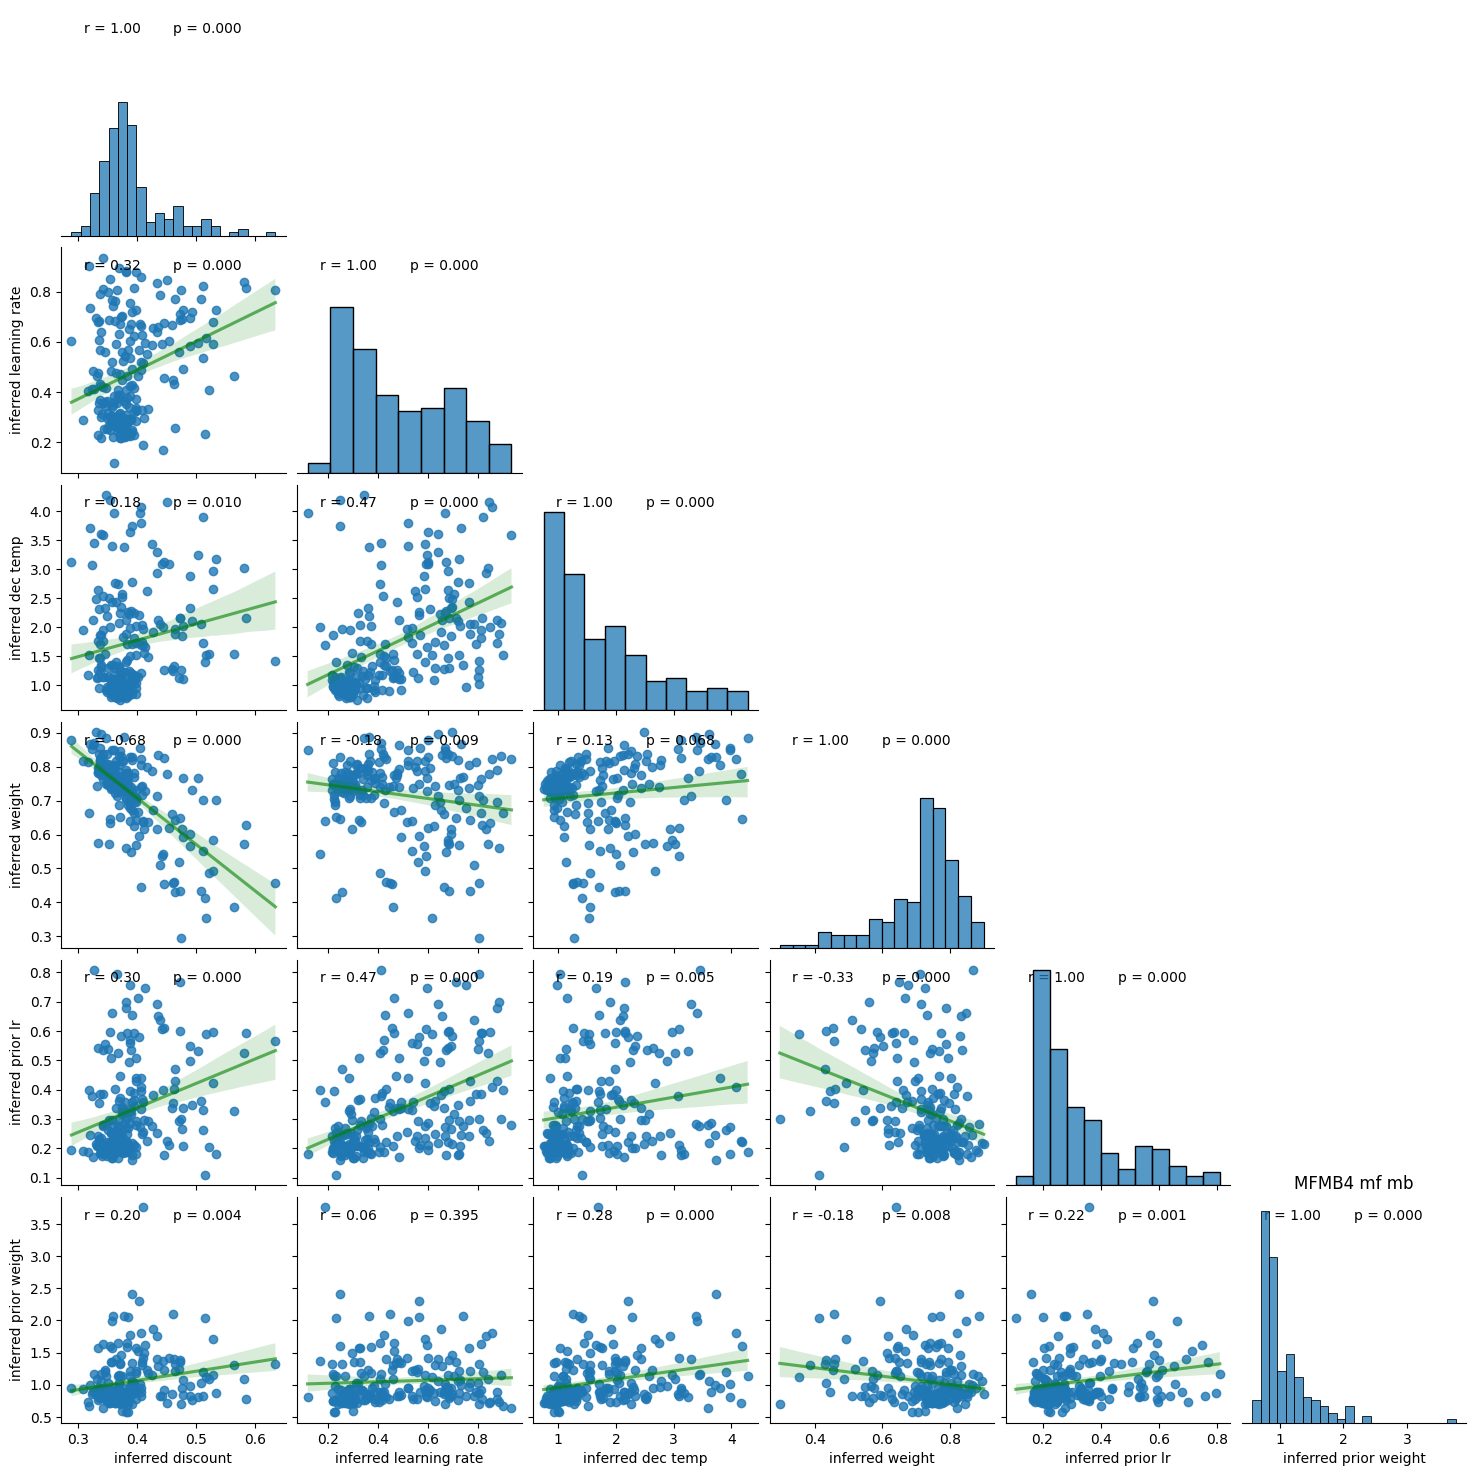

In [21]:
MFMB6_mf_mb_prior_fname_base = MFMB6_mf_mb_prior_agent_type+"_inference_"
print(MFMB6_mf_mb_prior_fname_base)
# define folder where we want to save data
MFMB6_mf_mb_prior_base_dir = os.path.join(inference_folder,MFMB6_mf_mb_prior_fname_base[:-1])

MFMB6_mf_mb_prior_mean_df, MFMB6_mf_mb_prior_sample_df, MFMB6_mf_mb_prior_locs_df = \
    load_MFMB_results(MFMB6_mf_mb_prior_agent_params["learn_prior"], MFMB6_mf_mb_prior_agent_params["use_orig"], 
                      MFMB6_mf_mb_prior_agent_params["use_p"], MFMB6_mf_mb_prior_agent_params["restrict_alpha"], 
                      MFMB6_mf_mb_prior_agent_params["min_alpha"], MFMB6_mf_mb_prior_agent_params["max_dt"], 
                      MFMB6_mf_mb_prior_base_dir, global_experiment_parameters, data["valid"], 
                      MFMB6_mf_mb_prior_fname_base, num_steps, 
                      data, MFMB6_mf_mb_prior_agent_params["param_names"])

plt.figure()
vars_of_interest = ["inferred "+name for name in param_names]
f = sns.pairplot(data=MFMB6_mf_mb_prior_mean_df, kind='reg', diag_kind="hist", corner=True,
                    plot_kws={'line_kws': {'color': 'green', 'alpha': 0.6}},
                    x_vars=vars_of_interest, y_vars=vars_of_interest)
f.map(tu.annot_corrfunc)
# for p, p_range in enumerate(param_ranges):
#     f.axes[2,p].set_xlim(p_range)
#     f.axes[p,0].set_ylim(p_range)
plt.title("MFMB4 mf mb")
#plt.savefig(os.path.join(base_dir, fname_str+"_pairplot_means_inferred_corr.svg"))
plt.show()

### Sanity check: did the BCC analyses yield consistent results in the parameters they share?

#### BCC2 planning and BCC4 planning repeptition

Plotting correlations between inferred parameters of the two analyses

Index(['Unnamed: 0 BCC2_p', 'inferred dec temp BCC2_p', 'subject BCC2_p',
       'inferred reward rate BCC2_p', 'Unnamed: 0 BCC4_p_r',
       'inferred dec temp BCC4_p_r', 'subject BCC4_p_r',
       'inferred reward rate BCC4_p_r', 'inferred habitual tendency BCC4_p_r',
       'inferred policy rate BCC4_p_r'],
      dtype='object')
['Unnamed: 0 BCC2_p', 'inferred dec temp BCC2_p', 'subject BCC2_p', 'inferred reward rate BCC2_p']
['Unnamed: 0 BCC4_p_r', 'inferred dec temp BCC4_p_r', 'subject BCC4_p_r', 'inferred reward rate BCC4_p_r', 'inferred habitual tendency BCC4_p_r', 'inferred policy rate BCC4_p_r']
Index(['Unnamed: 0 BCC4_p_r', 'inferred dec temp BCC4_p_r', 'subject BCC4_p_r',
       'inferred reward rate BCC4_p_r', 'inferred habitual tendency BCC4_p_r',
       'inferred policy rate BCC4_p_r'],
      dtype='object')


<Figure size 640x480 with 0 Axes>

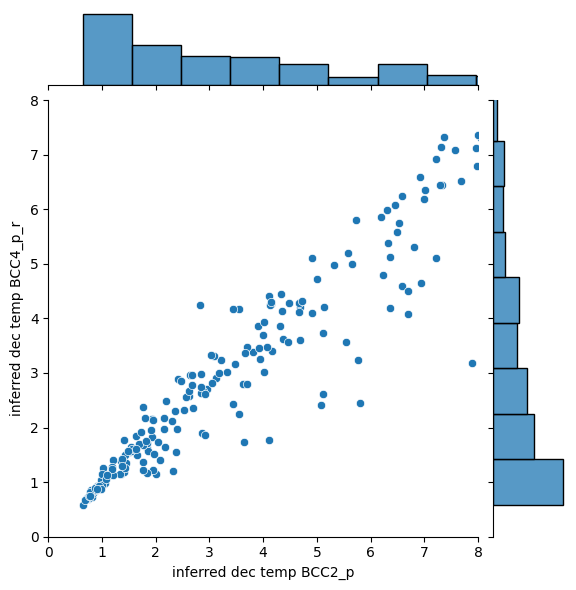

<Figure size 640x480 with 0 Axes>

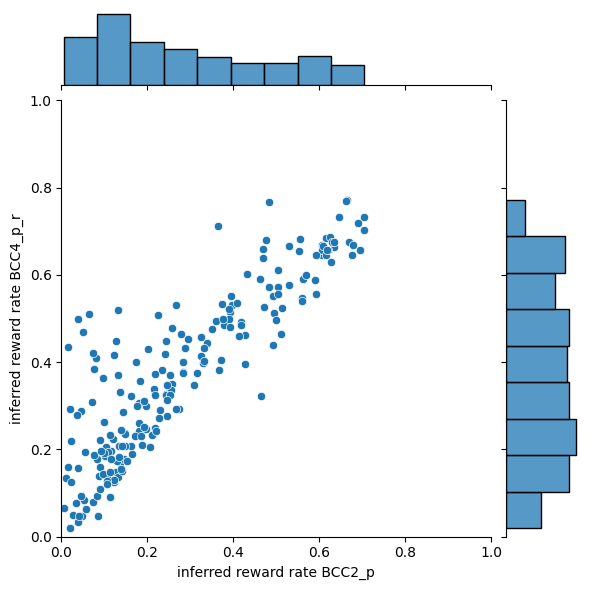

In [22]:
# compare the two results

concat_keys_BCC2_p = [name+" BCC2_p" for name in BCC2_p_mean_df.keys()]
concat_keys_BCC4_p_r = [name+" BCC4_p_r" for name in BCC4_p_r_mean_df.keys()]

new_name_dict_BCC2_p = {BCC2_p_mean_df.keys()[i]: concat_keys_BCC2_p[i] for i in range(len(concat_keys_BCC2_p))}
new_name_dict_BCC4_p_r= {BCC4_p_r_mean_df.keys()[i]: concat_keys_BCC4_p_r[i] for i in range(len(concat_keys_BCC4_p_r))}

renamed_BCC2_p = BCC2_p_mean_df.rename(columns=new_name_dict_BCC2_p)
renamed_BCC4_p_r= BCC4_p_r_mean_df.rename(columns=new_name_dict_BCC4_p_r)

BCC_means_df = pd.concat([renamed_BCC2_p, renamed_BCC4_p_r], axis='columns')#, join="inner")

print(BCC_means_df.keys())

print(concat_keys_BCC2_p)
print(concat_keys_BCC4_p_r)
print(renamed_BCC4_p_r.keys())

BCC2_p_param_names = BCC2_p_agent_params["param_names"]
BCC2_p_param_ranges = BCC2_p_agent_params["param_ranges"]

BCC2_p_vars_of_interest = ["inferred "+name+" BCC2_p" for name in BCC2_p_param_names]
BCC4_p_r_vars_of_interest = ["inferred "+name+" BCC4_p_r" for name in BCC2_p_param_names]

#plt.figure()
##sns.relplot(data=BCC2_p_means_df, )
#sns.pairplot(data=BCC2_p_means_df, x_vars=a1_vars_of_interest, y_vars=a2_vars_of_interest)#, x_vars = )
#plt.show()

for i, name in enumerate(BCC2_p_param_names):
    plt.figure()
    #sns.scatterplot(data=BCC2_p_means_df, x="inferred "+name+" analysis 1", y="inferred "+name+" analysis 2")
    sns.jointplot(data=BCC_means_df, x="inferred "+name+" BCC2_p", y="inferred "+name+" BCC4_p_r")
    plt.xlim(BCC2_p_param_ranges[i])
    plt.ylim(BCC2_p_param_ranges[i])
    #plt.title("inferred "+name+" BCC2_p + inferred "+name+" BCC4_p_r")
    plt.show()

#for i, name in enumerate(BCC_param_names[:-1]):
#    plt.figure()
#    #sns.scatterplot(data=BCC2_p_means_df, x="inferred "+name+" analysis 1", y="inferred "+name+" analysis 2")
#    sns.jointplot(data=BCC_means_df, x="inferred "+name+" BCC2_p", y="inferred habitual tendency BCC4_p_r")
#    plt.xlim(param_ranges[i])
#    #plt.ylim(param_ranges[i])
#    plt.show()

#### BCC2 planning and BCC4 planning cached

Plotting correlations between inferred parameters of the two analyses

Index(['Unnamed: 0 BCC2_p', 'inferred dec temp BCC2_p', 'subject BCC2_p',
       'inferred reward rate BCC2_p', 'Unnamed: 0 BCC4_p_c',
       'inferred dec temp BCC4_p_c', 'subject BCC4_p_c',
       'inferred reward rate BCC4_p_c', 'inferred cached weight BCC4_p_c',
       'inferred cached rate BCC4_p_c'],
      dtype='object')
['Unnamed: 0 BCC2_p', 'inferred dec temp BCC2_p', 'subject BCC2_p', 'inferred reward rate BCC2_p']
['Unnamed: 0 BCC4_p_c', 'inferred dec temp BCC4_p_c', 'subject BCC4_p_c', 'inferred reward rate BCC4_p_c', 'inferred cached weight BCC4_p_c', 'inferred cached rate BCC4_p_c']
Index(['Unnamed: 0 BCC4_p_c', 'inferred dec temp BCC4_p_c', 'subject BCC4_p_c',
       'inferred reward rate BCC4_p_c', 'inferred cached weight BCC4_p_c',
       'inferred cached rate BCC4_p_c'],
      dtype='object')


<Figure size 640x480 with 0 Axes>

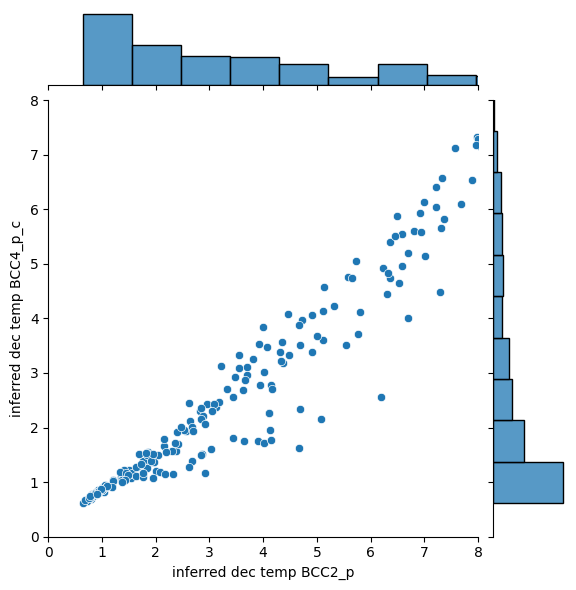

<Figure size 640x480 with 0 Axes>

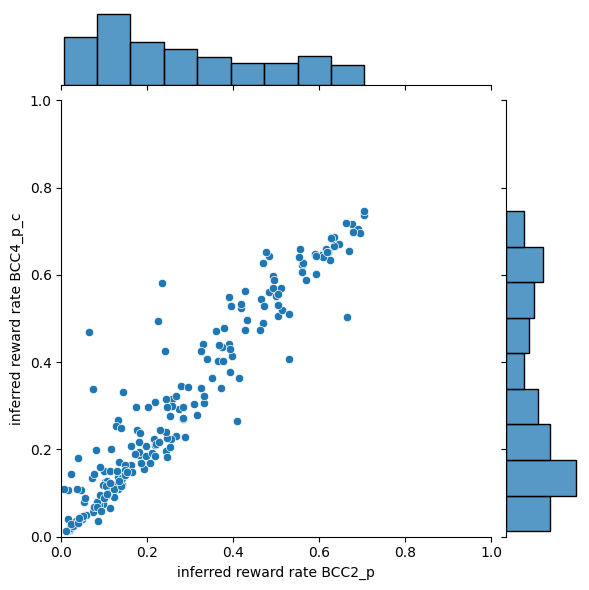

In [23]:
# compare the two results

concat_keys_BCC2_p = [name+" BCC2_p" for name in BCC2_p_mean_df.keys()]
concat_keys_BCC4_p_c = [name+" BCC4_p_c" for name in BCC4_p_c_mean_df.keys()]

new_name_dict_BCC2_p = {BCC2_p_mean_df.keys()[i]: concat_keys_BCC2_p[i] for i in range(len(concat_keys_BCC2_p))}
new_name_dict_BCC4_p_c= {BCC4_p_c_mean_df.keys()[i]: concat_keys_BCC4_p_c[i] for i in range(len(concat_keys_BCC4_p_c))}

renamed_BCC2_p = BCC2_p_mean_df.rename(columns=new_name_dict_BCC2_p)
renamed_BCC4_p_c= BCC4_p_c_mean_df.rename(columns=new_name_dict_BCC4_p_c)

BCC_means_df = pd.concat([renamed_BCC2_p, renamed_BCC4_p_c], axis='columns')#, join="inner")

print(BCC_means_df.keys())

print(concat_keys_BCC2_p)
print(concat_keys_BCC4_p_c)
print(renamed_BCC4_p_c.keys())

BCC2_p_param_names = BCC2_p_agent_params["param_names"]
BCC2_p_param_ranges = BCC2_p_agent_params["param_ranges"]

BCC2_p_vars_of_interest = ["inferred "+name+" BCC2_p" for name in BCC2_p_param_names]
BCC4_p_c_vars_of_interest = ["inferred "+name+" BCC4_p_c" for name in BCC2_p_param_names]

#plt.figure()
##sns.relplot(data=BCC2_p_means_df, )
#sns.pairplot(data=BCC2_p_means_df, x_vars=a1_vars_of_interest, y_vars=a2_vars_of_interest)#, x_vars = )
#plt.show()

for i, name in enumerate(BCC2_p_param_names):
    plt.figure()
    #sns.scatterplot(data=BCC2_p_means_df, x="inferred "+name+" analysis 1", y="inferred "+name+" analysis 2")
    sns.jointplot(data=BCC_means_df, x="inferred "+name+" BCC2_p", y="inferred "+name+" BCC4_p_c")
    plt.xlim(BCC2_p_param_ranges[i])
    plt.ylim(BCC2_p_param_ranges[i])
    #plt.title("inferred "+name+" BCC2_p + inferred "+name+" BCC4_p_c")
    plt.show()

#for i, name in enumerate(BCC_param_names[:-1]):
#    plt.figure()
#    #sns.scatterplot(data=BCC2_p_means_df, x="inferred "+name+" analysis 1", y="inferred "+name+" analysis 2")
#    sns.jointplot(data=BCC_means_df, x="inferred "+name+" BCC2_p", y="inferred habitual tendency BCC4_p_c")
#    plt.xlim(param_ranges[i])
#    #plt.ylim(param_ranges[i])
#    plt.show()

#### BCC4 planning repetition and BCC4 planning cached

Plotting correlations between inferred parameters of the two analyses

Index(['Unnamed: 0 BCC4_p_r', 'inferred dec temp BCC4_p_r', 'subject BCC4_p_r',
       'inferred reward rate BCC4_p_r', 'inferred habitual tendency BCC4_p_r',
       'inferred policy rate BCC4_p_r', 'Unnamed: 0 BCC4_p_c',
       'inferred dec temp BCC4_p_c', 'subject BCC4_p_c',
       'inferred reward rate BCC4_p_c', 'inferred cached weight BCC4_p_c',
       'inferred cached rate BCC4_p_c'],
      dtype='object')
['Unnamed: 0 BCC4_p_r', 'inferred dec temp BCC4_p_r', 'subject BCC4_p_r', 'inferred reward rate BCC4_p_r', 'inferred habitual tendency BCC4_p_r', 'inferred policy rate BCC4_p_r']
['Unnamed: 0 BCC4_p_c', 'inferred dec temp BCC4_p_c', 'subject BCC4_p_c', 'inferred reward rate BCC4_p_c', 'inferred cached weight BCC4_p_c', 'inferred cached rate BCC4_p_c']
Index(['Unnamed: 0 BCC4_p_c', 'inferred dec temp BCC4_p_c', 'subject BCC4_p_c',
       'inferred reward rate BCC4_p_c', 'inferred cached weight BCC4_p_c',
       'inferred cached rate BCC4_p_c'],
      dtype='object')


<Figure size 640x480 with 0 Axes>

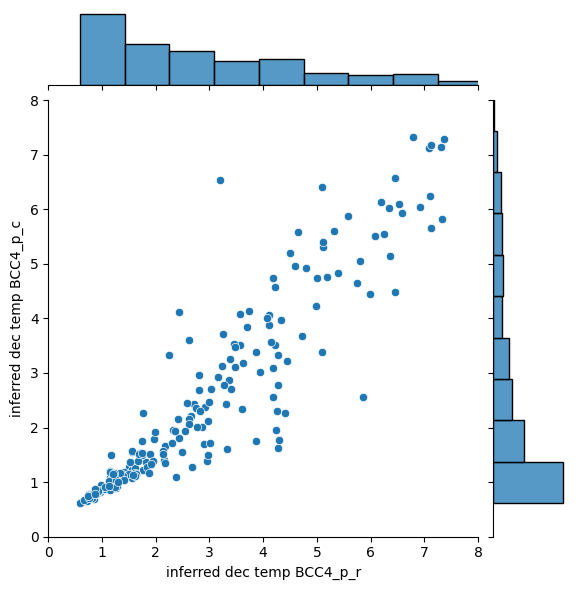

<Figure size 640x480 with 0 Axes>

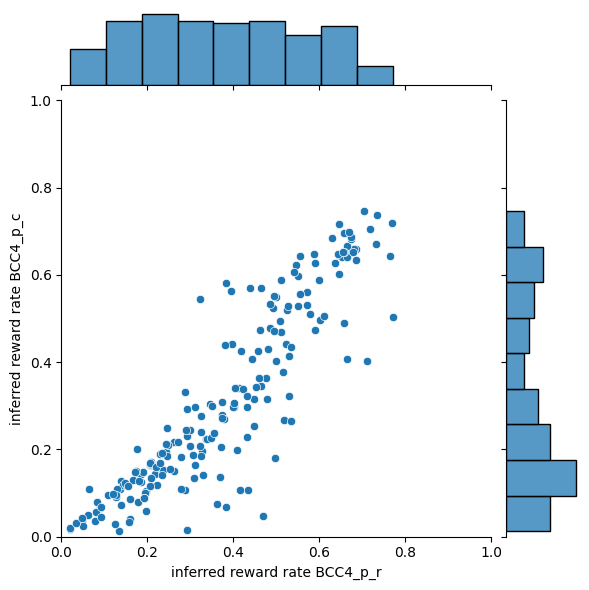

In [24]:
# compare the two results

concat_keys_BCC4_p_r = [name+" BCC4_p_r" for name in BCC4_p_r_mean_df.keys()]
concat_keys_BCC4_p_c = [name+" BCC4_p_c" for name in BCC4_p_c_mean_df.keys()]

new_name_dict_BCC4_p_r = {BCC4_p_r_mean_df.keys()[i]: concat_keys_BCC4_p_r[i] for i in range(len(concat_keys_BCC4_p_r))}
new_name_dict_BCC4_p_c= {BCC4_p_c_mean_df.keys()[i]: concat_keys_BCC4_p_c[i] for i in range(len(concat_keys_BCC4_p_c))}

renamed_BCC4_p_r = BCC4_p_r_mean_df.rename(columns=new_name_dict_BCC4_p_r)
renamed_BCC4_p_c= BCC4_p_c_mean_df.rename(columns=new_name_dict_BCC4_p_c)

BCC_means_df = pd.concat([renamed_BCC4_p_r, renamed_BCC4_p_c], axis='columns')#, join="inner")

print(BCC_means_df.keys())

print(concat_keys_BCC4_p_r)
print(concat_keys_BCC4_p_c)
print(renamed_BCC4_p_c.keys())

BCC2_p_param_names = BCC2_p_agent_params["param_names"]
BCC2_p_param_ranges = BCC2_p_agent_params["param_ranges"]

BCC4_p_r_vars_of_interest = ["inferred "+name+" BCC4_p_r" for name in BCC2_p_param_names]
BCC4_p_c_vars_of_interest = ["inferred "+name+" BCC4_p_c" for name in BCC2_p_param_names]

#plt.figure()
##sns.relplot(data=BCC2_p_means_df, )
#sns.pairplot(data=BCC2_p_means_df, x_vars=a1_vars_of_interest, y_vars=a2_vars_of_interest)#, x_vars = )
#plt.show()

for i, name in enumerate(BCC2_p_param_names):
    plt.figure()
    #sns.scatterplot(data=BCC2_p_means_df, x="inferred "+name+" analysis 1", y="inferred "+name+" analysis 2")
    sns.jointplot(data=BCC_means_df, x="inferred "+name+" BCC4_p_r", y="inferred "+name+" BCC4_p_c")
    plt.xlim(BCC2_p_param_ranges[i])
    plt.ylim(BCC2_p_param_ranges[i])
    #plt.title("inferred "+name+" BCC2_p + inferred "+name+" BCC4_p_c")
    plt.show()

#for i, name in enumerate(BCC_param_names[:-1]):
#    plt.figure()
#    #sns.scatterplot(data=BCC2_p_means_df, x="inferred "+name+" analysis 1", y="inferred "+name+" analysis 2")
#    sns.jointplot(data=BCC_means_df, x="inferred "+name+" BCC2_p", y="inferred habitual tendency BCC4_p_c")
#    plt.xlim(param_ranges[i])
#    #plt.ylim(param_ranges[i])
#    plt.show()

#### BCC2 planning and BCC6 planning repeptition cached

Plotting correlations between inferred parameters of the two analyses

Index(['Unnamed: 0 BCC2_p', 'inferred dec temp BCC2_p', 'subject BCC2_p',
       'inferred reward rate BCC2_p', 'Unnamed: 0 BCC6_p_r_c',
       'inferred dec temp BCC6_p_r_c', 'subject BCC6_p_r_c',
       'inferred reward rate BCC6_p_r_c',
       'inferred habitual tendency BCC6_p_r_c',
       'inferred policy rate BCC6_p_r_c', 'inferred cached weight BCC6_p_r_c',
       'inferred cached rate BCC6_p_r_c'],
      dtype='object')
['Unnamed: 0 BCC2_p', 'inferred dec temp BCC2_p', 'subject BCC2_p', 'inferred reward rate BCC2_p']
['Unnamed: 0 BCC6_p_r_c', 'inferred dec temp BCC6_p_r_c', 'subject BCC6_p_r_c', 'inferred reward rate BCC6_p_r_c', 'inferred habitual tendency BCC6_p_r_c', 'inferred policy rate BCC6_p_r_c', 'inferred cached weight BCC6_p_r_c', 'inferred cached rate BCC6_p_r_c']
Index(['Unnamed: 0 BCC6_p_r_c', 'inferred dec temp BCC6_p_r_c',
       'subject BCC6_p_r_c', 'inferred reward rate BCC6_p_r_c',
       'inferred habitual tendency BCC6_p_r_c',
       'inferred policy rate B

<Figure size 640x480 with 0 Axes>

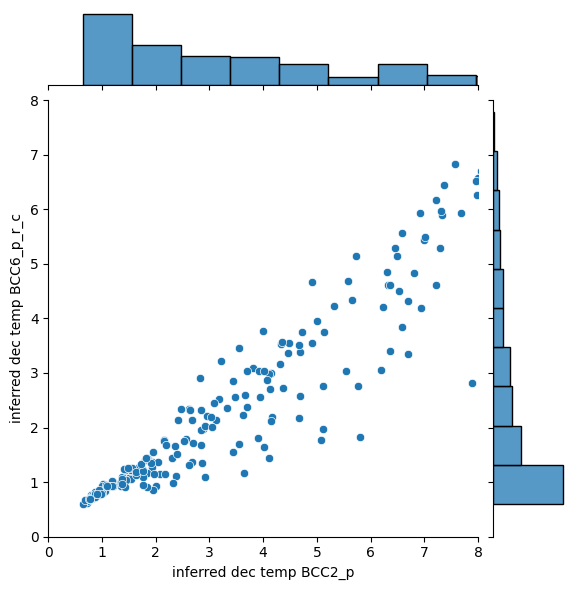

<Figure size 640x480 with 0 Axes>

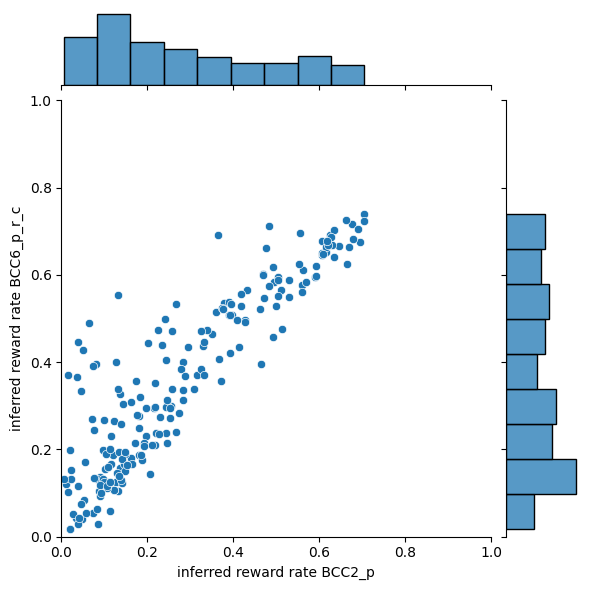

In [25]:
# compare the two results

concat_keys_BCC2_p = [name+" BCC2_p" for name in BCC2_p_mean_df.keys()]
concat_keys_BCC6_p_r_c = [name+" BCC6_p_r_c" for name in BCC6_p_r_c_mean_df.keys()]

new_name_dict_BCC2_p = {BCC2_p_mean_df.keys()[i]: concat_keys_BCC2_p[i] for i in range(len(concat_keys_BCC2_p))}
new_name_dict_BCC6_p_r_c= {BCC6_p_r_c_mean_df.keys()[i]: concat_keys_BCC6_p_r_c[i] for i in range(len(concat_keys_BCC6_p_r_c))}

renamed_BCC2_p = BCC2_p_mean_df.rename(columns=new_name_dict_BCC2_p)
renamed_BCC6_p_r_c= BCC6_p_r_c_mean_df.rename(columns=new_name_dict_BCC6_p_r_c)

BCC_means_df = pd.concat([renamed_BCC2_p, renamed_BCC6_p_r_c], axis='columns')#, join="inner")

print(BCC_means_df.keys())

print(concat_keys_BCC2_p)
print(concat_keys_BCC6_p_r_c)
print(renamed_BCC6_p_r_c.keys())

BCC2_p_param_names = BCC2_p_agent_params["param_names"]
BCC2_p_param_ranges = BCC2_p_agent_params["param_ranges"]

BCC2_p_vars_of_interest = ["inferred "+name+" BCC2_p" for name in BCC2_p_param_names]
BCC6_p_r_c_vars_of_interest = ["inferred "+name+" BCC6_p_r_c" for name in BCC2_p_param_names]

#plt.figure()
##sns.relplot(data=BCC2_p_means_df, )
#sns.pairplot(data=BCC2_p_means_df, x_vars=a1_vars_of_interest, y_vars=a2_vars_of_interest)#, x_vars = )
#plt.show()

for i, name in enumerate(BCC2_p_param_names):
    plt.figure()
    #sns.scatterplot(data=BCC2_p_means_df, x="inferred "+name+" analysis 1", y="inferred "+name+" analysis 2")
    sns.jointplot(data=BCC_means_df, x="inferred "+name+" BCC2_p", y="inferred "+name+" BCC6_p_r_c")
    plt.xlim(BCC2_p_param_ranges[i])
    plt.ylim(BCC2_p_param_ranges[i])
    #plt.title("inferred "+name+" BCC2_p + inferred "+name+" BCC6_p_r_c")
    plt.show()

#for i, name in enumerate(BCC_param_names[:-1]):
#    plt.figure()
#    #sns.scatterplot(data=BCC2_p_means_df, x="inferred "+name+" analysis 1", y="inferred "+name+" analysis 2")
#    sns.jointplot(data=BCC_means_df, x="inferred "+name+" BCC2_p", y="inferred habitual tendency BCC6_p_r_c")
#    plt.xlim(param_ranges[i])
#    #plt.ylim(param_ranges[i])
#    plt.show()

#### BCC6 planning repetition cached and BCC4 planning repetition

Plotting correlations between inferred parameters of the two analyses

Index(['Unnamed: 0 BCC4_p_r', 'inferred dec temp BCC4_p_r', 'subject BCC4_p_r',
       'inferred reward rate BCC4_p_r', 'inferred habitual tendency BCC4_p_r',
       'inferred policy rate BCC4_p_r', 'Unnamed: 0 BCC6_p_r_c',
       'inferred dec temp BCC6_p_r_c', 'subject BCC6_p_r_c',
       'inferred reward rate BCC6_p_r_c',
       'inferred habitual tendency BCC6_p_r_c',
       'inferred policy rate BCC6_p_r_c', 'inferred cached weight BCC6_p_r_c',
       'inferred cached rate BCC6_p_r_c'],
      dtype='object')
['Unnamed: 0 BCC4_p_r', 'inferred dec temp BCC4_p_r', 'subject BCC4_p_r', 'inferred reward rate BCC4_p_r', 'inferred habitual tendency BCC4_p_r', 'inferred policy rate BCC4_p_r']
['Unnamed: 0 BCC6_p_r_c', 'inferred dec temp BCC6_p_r_c', 'subject BCC6_p_r_c', 'inferred reward rate BCC6_p_r_c', 'inferred habitual tendency BCC6_p_r_c', 'inferred policy rate BCC6_p_r_c', 'inferred cached weight BCC6_p_r_c', 'inferred cached rate BCC6_p_r_c']
Index(['Unnamed: 0 BCC6_p_r_c', 'inferr

<Figure size 640x480 with 0 Axes>

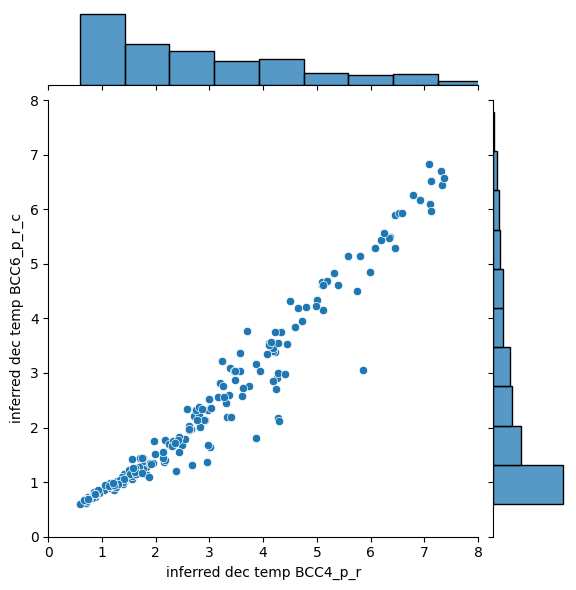

<Figure size 640x480 with 0 Axes>

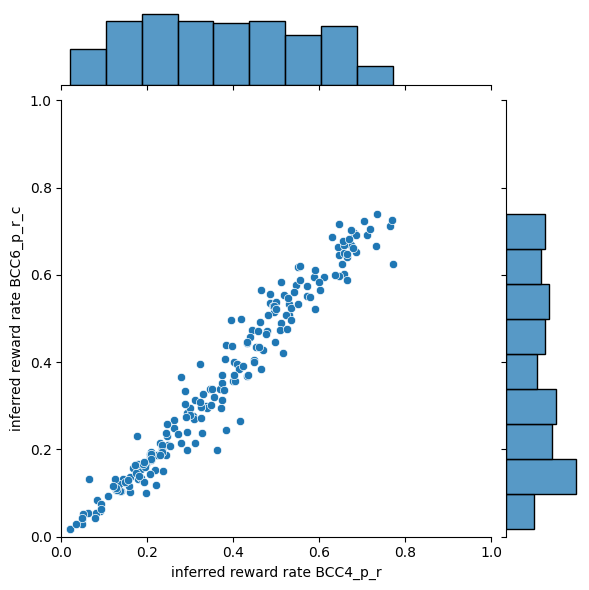

<Figure size 640x480 with 0 Axes>

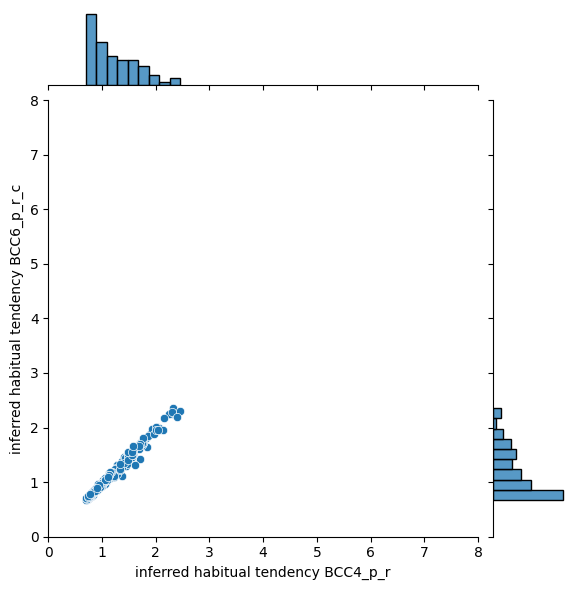

<Figure size 640x480 with 0 Axes>

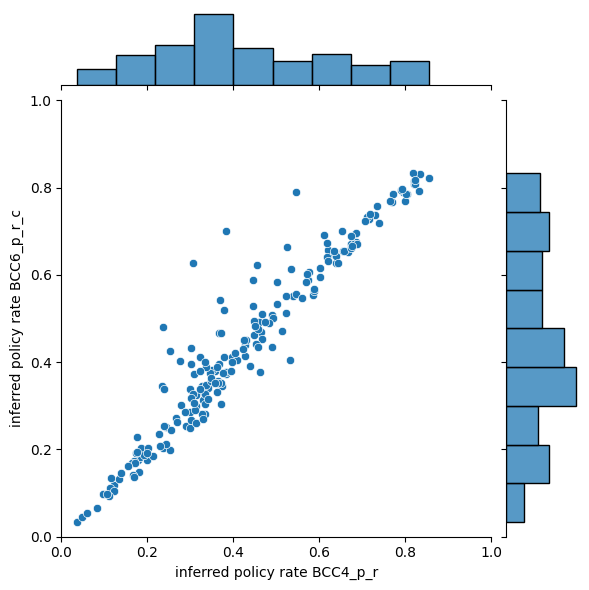

In [26]:
# compare the two results

concat_keys_BCC4_p_r = [name+" BCC4_p_r" for name in BCC4_p_r_mean_df.keys()]
concat_keys_BCC6_p_r_c = [name+" BCC6_p_r_c" for name in BCC6_p_r_c_mean_df.keys()]

new_name_dict_BCC4_p_r = {BCC4_p_r_mean_df.keys()[i]: concat_keys_BCC4_p_r[i] for i in range(len(concat_keys_BCC4_p_r))}
new_name_dict_BCC6_p_r_c= {BCC6_p_r_c_mean_df.keys()[i]: concat_keys_BCC6_p_r_c[i] for i in range(len(concat_keys_BCC6_p_r_c))}

renamed_BCC4_p_r = BCC4_p_r_mean_df.rename(columns=new_name_dict_BCC4_p_r)
renamed_BCC6_p_r_c= BCC6_p_r_c_mean_df.rename(columns=new_name_dict_BCC6_p_r_c)

BCC_means_df = pd.concat([renamed_BCC4_p_r, renamed_BCC6_p_r_c], axis='columns')#, join="inner")

print(BCC_means_df.keys())

print(concat_keys_BCC4_p_r)
print(concat_keys_BCC6_p_r_c)
print(renamed_BCC6_p_r_c.keys())

BCC4_p_r_param_names = BCC4_p_r_agent_params["param_names"]
BCC4_p_r_param_ranges = BCC4_p_r_agent_params["param_ranges"]

BCC4_p_r_vars_of_interest = ["inferred "+name+" BCC4_p_r" for name in BCC4_p_r_param_names]
BCC6_p_r_c_vars_of_interest = ["inferred "+name+" BCC6_p_r_c" for name in BCC4_p_r_param_names]

#plt.figure()
##sns.relplot(data=BCC2_p_means_df, )
#sns.pairplot(data=BCC2_p_means_df, x_vars=a1_vars_of_interest, y_vars=a2_vars_of_interest)#, x_vars = )
#plt.show()

for i, name in enumerate(BCC4_p_r_param_names):
    plt.figure()
    #sns.scatterplot(data=BCC2_p_means_df, x="inferred "+name+" analysis 1", y="inferred "+name+" analysis 2")
    sns.jointplot(data=BCC_means_df, x="inferred "+name+" BCC4_p_r", y="inferred "+name+" BCC6_p_r_c")
    plt.xlim(BCC4_p_r_param_ranges[i])
    plt.ylim(BCC4_p_r_param_ranges[i])
    #plt.title("inferred "+name+" BCC2_p + inferred "+name+" BCC6_p_r_c")
    plt.show()

#for i, name in enumerate(BCC_param_names[:-1]):
#    plt.figure()
#    #sns.scatterplot(data=BCC2_p_means_df, x="inferred "+name+" analysis 1", y="inferred "+name+" analysis 2")
#    sns.jointplot(data=BCC_means_df, x="inferred "+name+" BCC2_p", y="inferred habitual tendency BCC6_p_r_c")
#    plt.xlim(param_ranges[i])
#    #plt.ylim(param_ranges[i])
#    plt.show()

#### BCC6 planning repetition cached and BCC4 planning cached

Plotting correlations between inferred parameters of the two analyses

Index(['Unnamed: 0 BCC4_p_c', 'inferred dec temp BCC4_p_c', 'subject BCC4_p_c',
       'inferred reward rate BCC4_p_c', 'inferred cached weight BCC4_p_c',
       'inferred cached rate BCC4_p_c', 'Unnamed: 0 BCC6_p_r_c',
       'inferred dec temp BCC6_p_r_c', 'subject BCC6_p_r_c',
       'inferred reward rate BCC6_p_r_c',
       'inferred habitual tendency BCC6_p_r_c',
       'inferred policy rate BCC6_p_r_c', 'inferred cached weight BCC6_p_r_c',
       'inferred cached rate BCC6_p_r_c'],
      dtype='object')
['Unnamed: 0 BCC4_p_c', 'inferred dec temp BCC4_p_c', 'subject BCC4_p_c', 'inferred reward rate BCC4_p_c', 'inferred cached weight BCC4_p_c', 'inferred cached rate BCC4_p_c']
['Unnamed: 0 BCC6_p_r_c', 'inferred dec temp BCC6_p_r_c', 'subject BCC6_p_r_c', 'inferred reward rate BCC6_p_r_c', 'inferred habitual tendency BCC6_p_r_c', 'inferred policy rate BCC6_p_r_c', 'inferred cached weight BCC6_p_r_c', 'inferred cached rate BCC6_p_r_c']
Index(['Unnamed: 0 BCC6_p_r_c', 'inferred dec t

<Figure size 640x480 with 0 Axes>

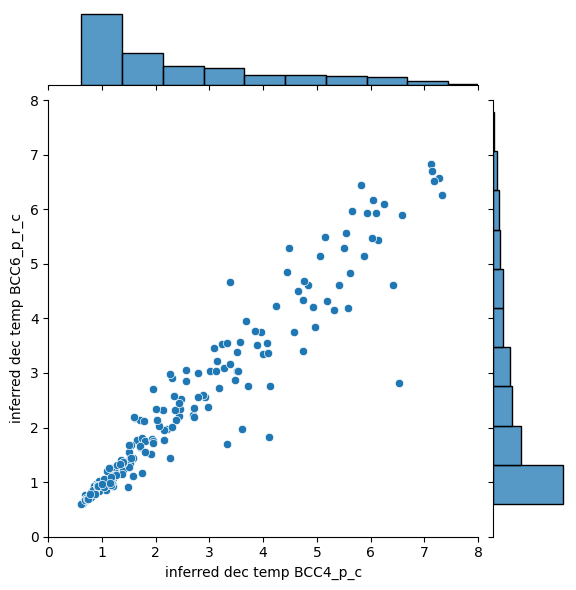

<Figure size 640x480 with 0 Axes>

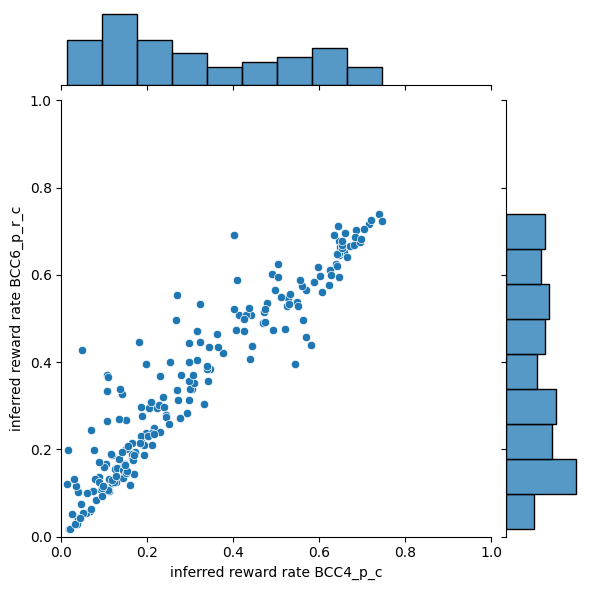

<Figure size 640x480 with 0 Axes>

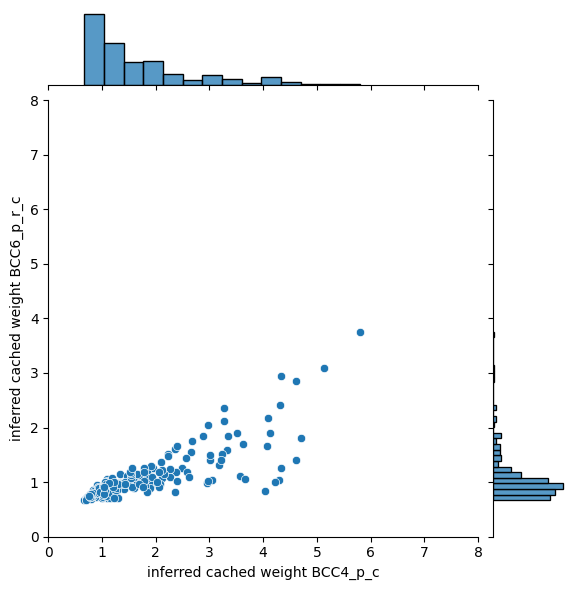

<Figure size 640x480 with 0 Axes>

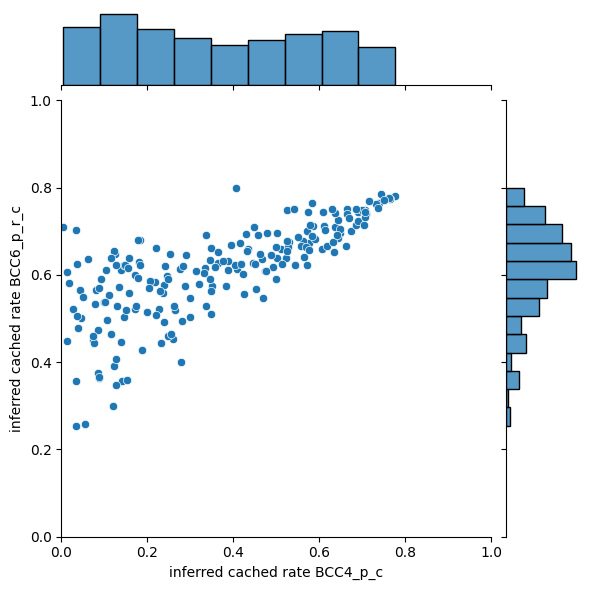

In [27]:
# compare the two results

concat_keys_BCC4_p_c = [name+" BCC4_p_c" for name in BCC4_p_c_mean_df.keys()]
concat_keys_BCC6_p_r_c = [name+" BCC6_p_r_c" for name in BCC6_p_r_c_mean_df.keys()]

new_name_dict_BCC4_p_c = {BCC4_p_c_mean_df.keys()[i]: concat_keys_BCC4_p_c[i] for i in range(len(concat_keys_BCC4_p_c))}
new_name_dict_BCC6_p_r_c= {BCC6_p_r_c_mean_df.keys()[i]: concat_keys_BCC6_p_r_c[i] for i in range(len(concat_keys_BCC6_p_r_c))}

renamed_BCC4_p_c = BCC4_p_c_mean_df.rename(columns=new_name_dict_BCC4_p_c)
renamed_BCC6_p_r_c= BCC6_p_r_c_mean_df.rename(columns=new_name_dict_BCC6_p_r_c)

BCC_means_df = pd.concat([renamed_BCC4_p_c, renamed_BCC6_p_r_c], axis='columns')#, join="inner")

print(BCC_means_df.keys())

print(concat_keys_BCC4_p_c)
print(concat_keys_BCC6_p_r_c)
print(renamed_BCC6_p_r_c.keys())

BCC4_p_c_param_names = BCC4_p_c_agent_params["param_names"]
BCC4_p_c_param_ranges = BCC4_p_c_agent_params["param_ranges"]

BCC4_p_c_vars_of_interest = ["inferred "+name+" BCC4_p_c" for name in BCC4_p_c_param_names]
BCC6_p_r_c_vars_of_interest = ["inferred "+name+" BCC6_p_r_c" for name in BCC4_p_c_param_names]

#plt.figure()
##sns.relplot(data=BCC2_p_means_df, )
#sns.pairplot(data=BCC2_p_means_df, x_vars=a1_vars_of_interest, y_vars=a2_vars_of_interest)#, x_vars = )
#plt.show()

for i, name in enumerate(BCC4_p_c_param_names):
    plt.figure()
    #sns.scatterplot(data=BCC2_p_means_df, x="inferred "+name+" analysis 1", y="inferred "+name+" analysis 2")
    sns.jointplot(data=BCC_means_df, x="inferred "+name+" BCC4_p_c", y="inferred "+name+" BCC6_p_r_c")
    plt.xlim(BCC4_p_c_param_ranges[i])
    plt.ylim(BCC4_p_c_param_ranges[i])
    #plt.title("inferred "+name+" BCC2_p + inferred "+name+" BCC6_p_r_c")
    plt.show()

#for i, name in enumerate(BCC_param_names[:-1]):
#    plt.figure()
#    #sns.scatterplot(data=BCC2_p_means_df, x="inferred "+name+" analysis 1", y="inferred "+name+" analysis 2")
#    sns.jointplot(data=BCC_means_df, x="inferred "+name+" BCC2_p", y="inferred habitual tendency BCC6_p_r_c")
#    plt.xlim(param_ranges[i])
#    #plt.ylim(param_ranges[i])
#    plt.show()

### Sanity check: did the MFMB4 and MFMB6 analyses yield consistent results in the parameters they share?

Plotting correlations between inferred parameters of the two analyses

Index(['Unnamed: 0 MFMB4', 'inferred discount MFMB4', 'subject MFMB4',
       'inferred learning rate MFMB4', 'inferred dec temp MFMB4',
       'inferred weight MFMB4', 'Unnamed: 0 MFMB6', 'inferred discount MFMB6',
       'subject MFMB6', 'inferred learning rate MFMB6',
       'inferred dec temp MFMB6', 'inferred weight MFMB6',
       'inferred prior lr MFMB6', 'inferred prior weight MFMB6'],
      dtype='object')
['Unnamed: 0 MFMB4', 'inferred discount MFMB4', 'subject MFMB4', 'inferred learning rate MFMB4', 'inferred dec temp MFMB4', 'inferred weight MFMB4']
['Unnamed: 0 MFMB6', 'inferred discount MFMB6', 'subject MFMB6', 'inferred learning rate MFMB6', 'inferred dec temp MFMB6', 'inferred weight MFMB6', 'inferred prior lr MFMB6', 'inferred prior weight MFMB6']
Index(['Unnamed: 0 MFMB4', 'inferred discount MFMB4', 'subject MFMB4',
       'inferred learning rate MFMB4', 'inferred dec temp MFMB4',
       'inferred weight MFMB4'],
      dtype='object')


<Figure size 640x480 with 0 Axes>

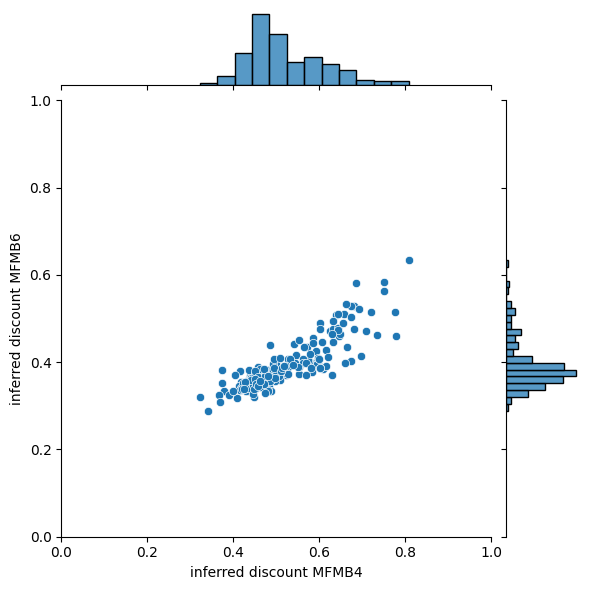

<Figure size 640x480 with 0 Axes>

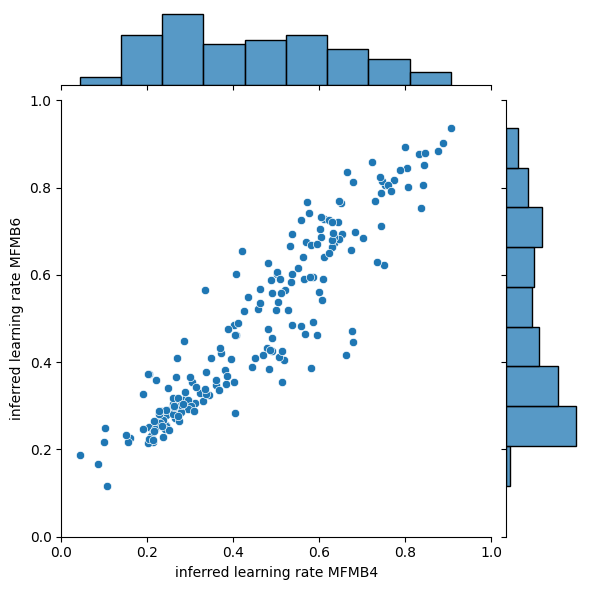

<Figure size 640x480 with 0 Axes>

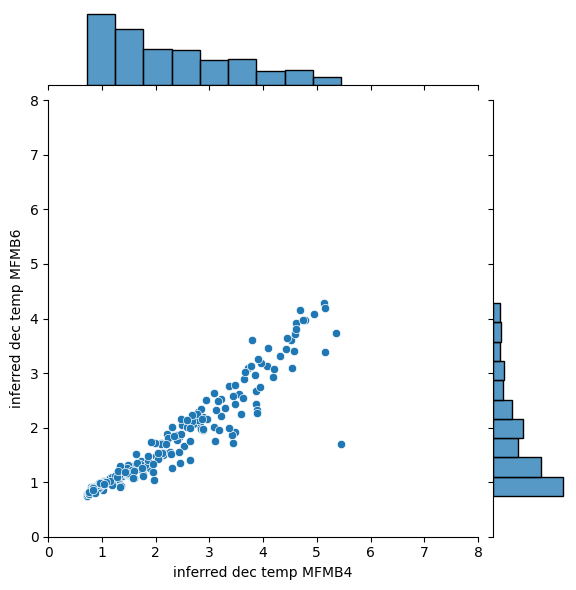

<Figure size 640x480 with 0 Axes>

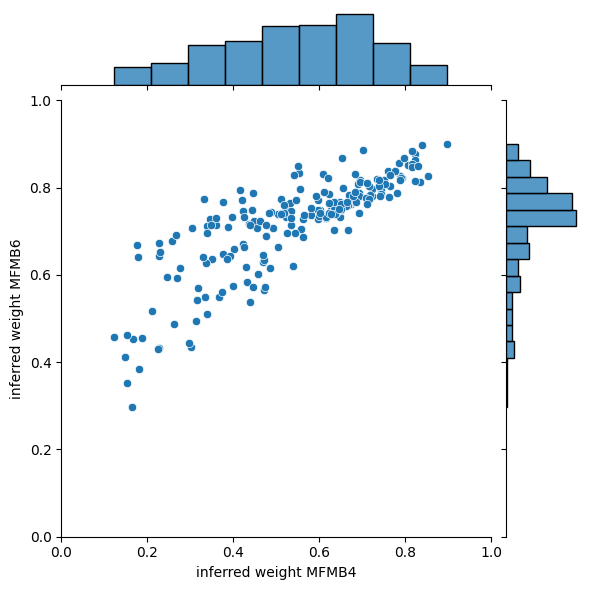

In [28]:
# compare the two results

concat_keys_MFMB4 = [name+" MFMB4" for name in MFMB4_mf_mb_mean_df.keys()]
concat_keys_MFMB6 = [name+" MFMB6" for name in MFMB6_mf_mb_prior_mean_df.keys()]

new_name_dict_MFMB4 = {MFMB4_mf_mb_mean_df.keys()[i]: concat_keys_MFMB4[i] for i in range(len(concat_keys_MFMB4))}
new_name_dict_MFMB6 = {MFMB6_mf_mb_prior_mean_df.keys()[i]: concat_keys_MFMB6[i] for i in range(len(concat_keys_MFMB6))}

renamed_MFMB4 = MFMB4_mf_mb_mean_df.rename(columns=new_name_dict_MFMB4)
renamed_MFMB6 = MFMB6_mf_mb_prior_mean_df.rename(columns=new_name_dict_MFMB6)

MFMB_means_df = pd.concat([renamed_MFMB4, renamed_MFMB6], axis='columns')#, join="inner")

print(MFMB_means_df.keys())

print(concat_keys_MFMB4)
print(concat_keys_MFMB6)
print(renamed_MFMB4.keys())

MFMB4_param_names = MFMB4_mf_mb_agent_params["param_names"]
MFMB4_param_ranges = MFMB4_mf_mb_agent_params["param_ranges"]

MFMB4_vars_of_interest = ["inferred "+name+" MFMB4" for name in MFMB4_param_names]
MFMB6_vars_of_interest = ["inferred "+name+" MFMB6" for name in MFMB4_param_names]

for i, name in enumerate(MFMB4_param_names):
    plt.figure()
    sns.jointplot(data=MFMB_means_df, x="inferred "+name+" MFMB4", y="inferred "+name+" MFMB6")
    plt.xlim(MFMB4_param_ranges[i])
    plt.ylim(MFMB4_param_ranges[i])
    plt.show()

### Compare inferences between the BCC and MFMB models:

using the BCC2_p and the MFMB4 model for the comparison

Index(['Unnamed: 0 BCC2_p', 'inferred dec temp BCC2_p', 'subject BCC2_p',
       'inferred reward rate BCC2_p', 'Unnamed: 0 MFMB4',
       'inferred discount MFMB4', 'subject MFMB4',
       'inferred learning rate MFMB4', 'inferred dec temp MFMB4',
       'inferred weight MFMB4'],
      dtype='object')
['inferred dec temp BCC2_p', 'inferred reward rate BCC2_p']
['inferred discount MFMB4', 'inferred learning rate MFMB4', 'inferred dec temp MFMB4', 'inferred weight MFMB4']


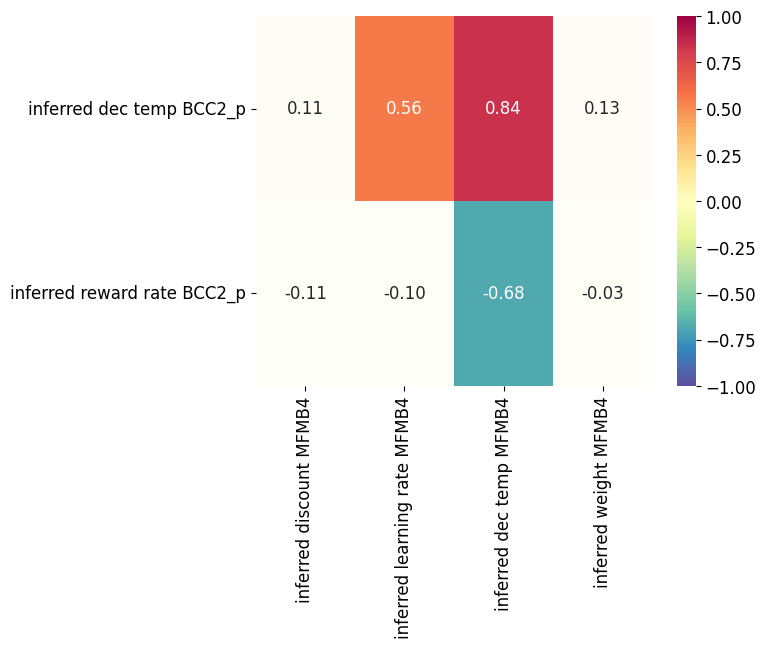

In [29]:
# compare BCC and MBMF4 results

BCC2_p_MBMF4_means_df = pd.concat([renamed_BCC2_p, renamed_MFMB4], axis='columns')#, join="inner")

print(BCC2_p_MBMF4_means_df.keys())

y_vars_of_interest = ["inferred "+name+" MFMB4" for name in MFMB4_param_names]
x_vars_of_interest = ["inferred "+name+" BCC2_p" for name in BCC2_p_param_names]

print(x_vars_of_interest)
print(y_vars_of_interest)

iu.plot_correlations(BCC2_p_MBMF4_means_df, x_vars_of_interest, y_vars_of_interest)

using the BCC2_p_r and the MFMB4 model for the comparison

Index(['Unnamed: 0 BCC4_p_r', 'inferred dec temp BCC4_p_r', 'subject BCC4_p_r',
       'inferred reward rate BCC4_p_r', 'inferred habitual tendency BCC4_p_r',
       'inferred policy rate BCC4_p_r', 'Unnamed: 0 MFMB4',
       'inferred discount MFMB4', 'subject MFMB4',
       'inferred learning rate MFMB4', 'inferred dec temp MFMB4',
       'inferred weight MFMB4'],
      dtype='object')
['inferred dec temp BCC4_p_r', 'inferred reward rate BCC4_p_r', 'inferred habitual tendency BCC4_p_r', 'inferred policy rate BCC4_p_r']
['inferred discount MFMB4', 'inferred learning rate MFMB4', 'inferred dec temp MFMB4', 'inferred weight MFMB4']


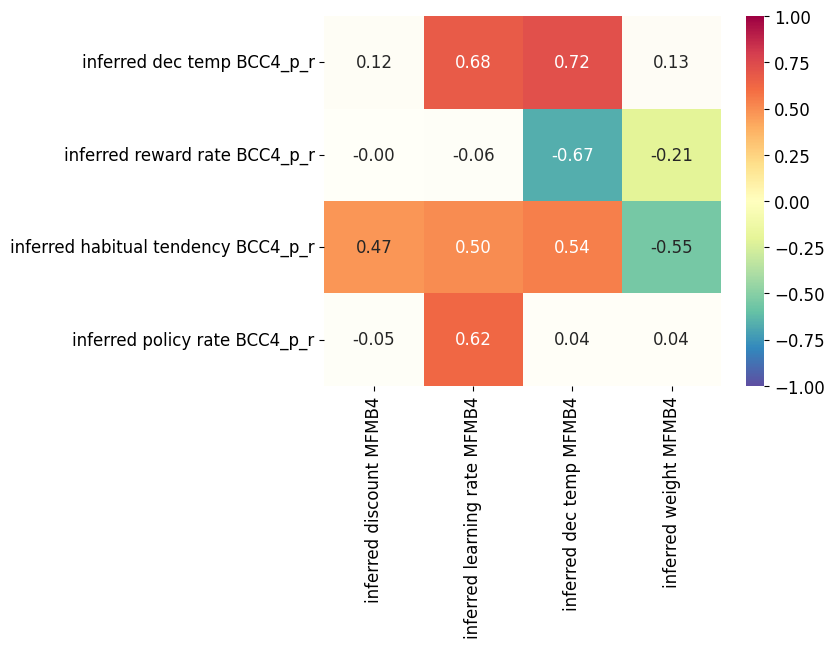

In [30]:
# compare BCC and MBMF4 results

BCC4_p_r_MBMF4_means_df = pd.concat([renamed_BCC4_p_r, renamed_MFMB4], axis='columns')#, join="inner")

print(BCC4_p_r_MBMF4_means_df.keys())

y_vars_of_interest = ["inferred "+name+" MFMB4" for name in MFMB4_param_names]
x_vars_of_interest = ["inferred "+name+" BCC4_p_r" for name in BCC4_p_r_param_names]

print(x_vars_of_interest)
print(y_vars_of_interest)

iu.plot_correlations(BCC4_p_r_MBMF4_means_df, x_vars_of_interest, y_vars_of_interest)

using the BCC2_p_c and the MFMB4 model for the comparison

Index(['Unnamed: 0 BCC4_p_c', 'inferred dec temp BCC4_p_c', 'subject BCC4_p_c',
       'inferred reward rate BCC4_p_c', 'inferred cached weight BCC4_p_c',
       'inferred cached rate BCC4_p_c', 'Unnamed: 0 MFMB4',
       'inferred discount MFMB4', 'subject MFMB4',
       'inferred learning rate MFMB4', 'inferred dec temp MFMB4',
       'inferred weight MFMB4'],
      dtype='object')
['inferred dec temp BCC4_p_c', 'inferred reward rate BCC4_p_c', 'inferred cached weight BCC4_p_c', 'inferred cached rate BCC4_p_c']
['inferred discount MFMB4', 'inferred learning rate MFMB4', 'inferred dec temp MFMB4', 'inferred weight MFMB4']


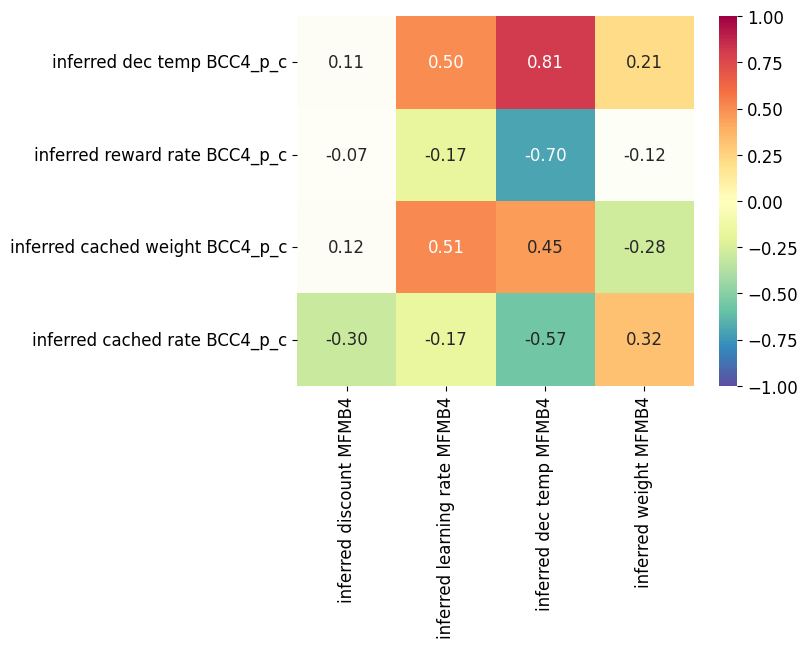

In [31]:
# compare BCC and MBMF4 results

BCC4_p_c_MBMF4_means_df = pd.concat([renamed_BCC4_p_c, renamed_MFMB4], axis='columns')#, join="inner")

print(BCC4_p_c_MBMF4_means_df.keys())

y_vars_of_interest = ["inferred "+name+" MFMB4" for name in MFMB4_param_names]
x_vars_of_interest = ["inferred "+name+" BCC4_p_c" for name in BCC4_p_c_param_names]

print(x_vars_of_interest)
print(y_vars_of_interest)

iu.plot_correlations(BCC4_p_c_MBMF4_means_df, x_vars_of_interest, y_vars_of_interest)

using the BCC6_p_r_c and the MFMB4 model for the comparison

Index(['Unnamed: 0 BCC6_p_r_c', 'inferred dec temp BCC6_p_r_c',
       'subject BCC6_p_r_c', 'inferred reward rate BCC6_p_r_c',
       'inferred habitual tendency BCC6_p_r_c',
       'inferred policy rate BCC6_p_r_c', 'inferred cached weight BCC6_p_r_c',
       'inferred cached rate BCC6_p_r_c', 'Unnamed: 0 MFMB4',
       'inferred discount MFMB4', 'subject MFMB4',
       'inferred learning rate MFMB4', 'inferred dec temp MFMB4',
       'inferred weight MFMB4'],
      dtype='object')
['inferred dec temp BCC6_p_r_c', 'inferred reward rate BCC6_p_r_c', 'inferred habitual tendency BCC6_p_r_c', 'inferred policy rate BCC6_p_r_c', 'inferred cached weight BCC6_p_r_c', 'inferred cached rate BCC6_p_r_c']
['inferred discount MFMB4', 'inferred learning rate MFMB4', 'inferred dec temp MFMB4', 'inferred weight MFMB4']


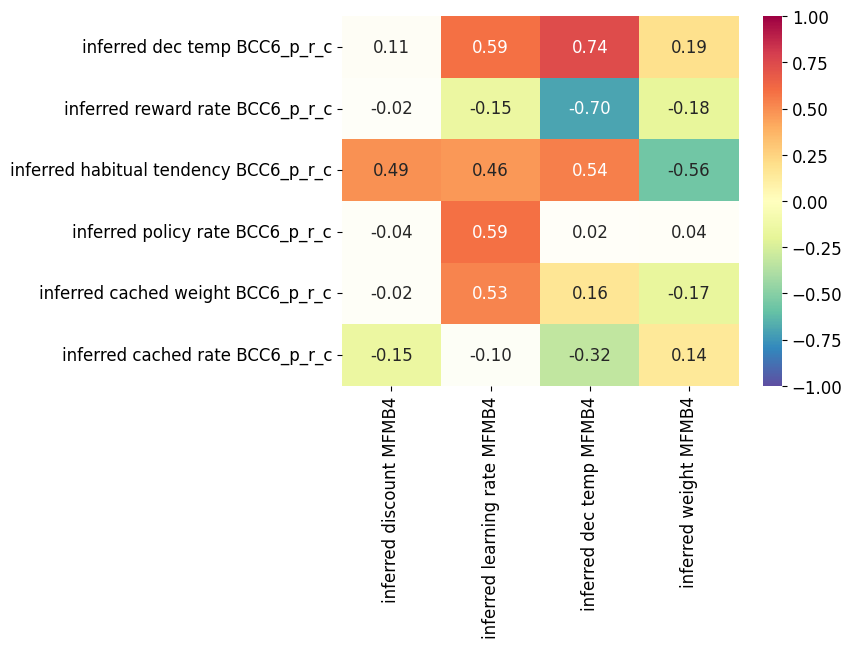

In [32]:
# compare BCC and MBMF4 results

BCC6_p_r_c_MBMF4_means_df = pd.concat([renamed_BCC6_p_r_c, renamed_MFMB4], axis='columns')#, join="inner")

print(BCC6_p_r_c_MBMF4_means_df.keys())

BCC6_p_r_c_param_names = BCC6_p_r_c_agent_params["param_names"]

y_vars_of_interest = ["inferred "+name+" MFMB4" for name in MFMB4_param_names]
x_vars_of_interest = ["inferred "+name+" BCC6_p_r_c" for name in BCC6_p_r_c_param_names]

print(x_vars_of_interest)
print(y_vars_of_interest)

iu.plot_correlations(BCC6_p_r_c_MBMF4_means_df, x_vars_of_interest, y_vars_of_interest)

using the BCC2_p and the MFMB6 model for the comparison

Index(['Unnamed: 0 BCC2_p', 'inferred dec temp BCC2_p', 'subject BCC2_p',
       'inferred reward rate BCC2_p', 'Unnamed: 0 MFMB6',
       'inferred discount MFMB6', 'subject MFMB6',
       'inferred learning rate MFMB6', 'inferred dec temp MFMB6',
       'inferred weight MFMB6', 'inferred prior lr MFMB6',
       'inferred prior weight MFMB6'],
      dtype='object')
['inferred dec temp BCC2_p', 'inferred reward rate BCC2_p']
['inferred discount MFMB6', 'inferred learning rate MFMB6', 'inferred dec temp MFMB6', 'inferred weight MFMB6', 'inferred prior lr MFMB6', 'inferred prior weight MFMB6']


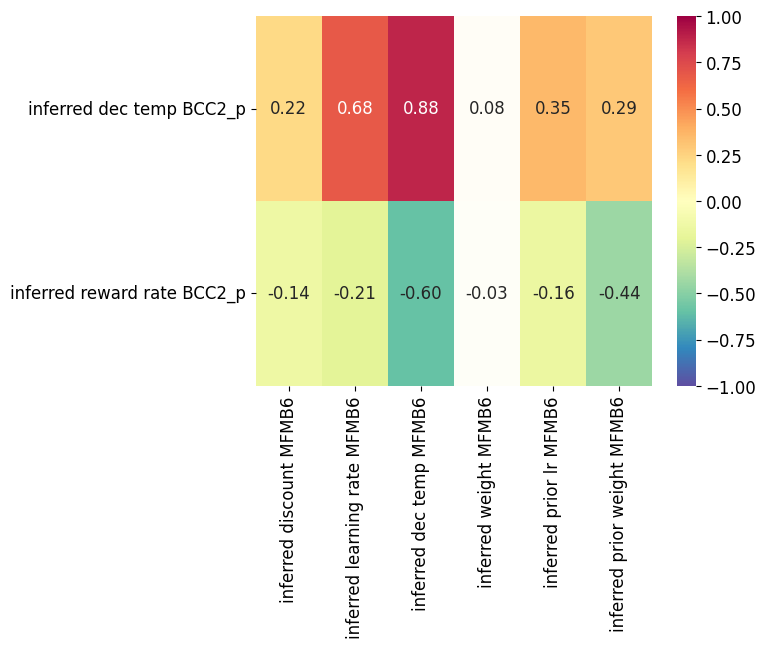

In [33]:
# compare BCC and MFMB6 results

BCC2_p_MFMB6_means_df = pd.concat([renamed_BCC2_p, renamed_MFMB6], axis='columns')#, join="inner")

print(BCC2_p_MFMB6_means_df.keys())

MFMB6_param_names = MFMB6_mf_mb_prior_agent_params["param_names"]

y_vars_of_interest = ["inferred "+name+" MFMB6" for name in MFMB6_param_names]
x_vars_of_interest = ["inferred "+name+" BCC2_p" for name in BCC2_p_param_names]

print(x_vars_of_interest)
print(y_vars_of_interest)

iu.plot_correlations(BCC2_p_MFMB6_means_df, x_vars_of_interest, y_vars_of_interest)

using the BCC2_p_r and the MFMB6 model for the comparison

Index(['Unnamed: 0 BCC4_p_r', 'inferred dec temp BCC4_p_r', 'subject BCC4_p_r',
       'inferred reward rate BCC4_p_r', 'inferred habitual tendency BCC4_p_r',
       'inferred policy rate BCC4_p_r', 'Unnamed: 0 MFMB6',
       'inferred discount MFMB6', 'subject MFMB6',
       'inferred learning rate MFMB6', 'inferred dec temp MFMB6',
       'inferred weight MFMB6', 'inferred prior lr MFMB6',
       'inferred prior weight MFMB6'],
      dtype='object')
['inferred dec temp BCC4_p_r', 'inferred reward rate BCC4_p_r', 'inferred habitual tendency BCC4_p_r', 'inferred policy rate BCC4_p_r']
['inferred discount MFMB6', 'inferred learning rate MFMB6', 'inferred dec temp MFMB6', 'inferred weight MFMB6', 'inferred prior lr MFMB6', 'inferred prior weight MFMB6']


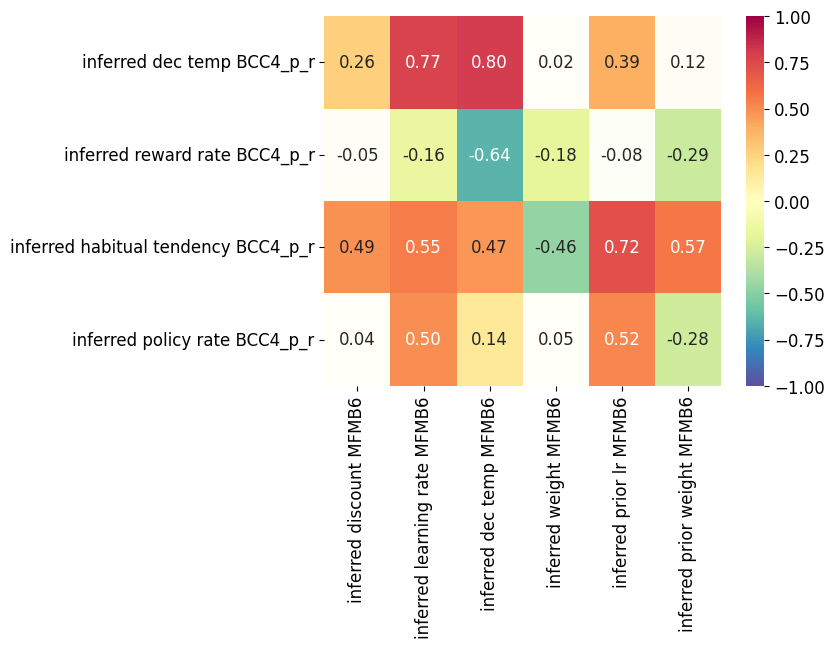

In [34]:
# compare BCC and MFMB6 results

BCC4_p_r_MFMB6_means_df = pd.concat([renamed_BCC4_p_r, renamed_MFMB6], axis='columns')#, join="inner")

print(BCC4_p_r_MFMB6_means_df.keys())

y_vars_of_interest = ["inferred "+name+" MFMB6" for name in MFMB6_param_names]
x_vars_of_interest = ["inferred "+name+" BCC4_p_r" for name in BCC4_p_r_param_names]

print(x_vars_of_interest)
print(y_vars_of_interest)

iu.plot_correlations(BCC4_p_r_MFMB6_means_df, x_vars_of_interest, y_vars_of_interest)

using the BCC2_p_c and the MFMB6 model for the comparison

Index(['Unnamed: 0 BCC4_p_c', 'inferred dec temp BCC4_p_c', 'subject BCC4_p_c',
       'inferred reward rate BCC4_p_c', 'inferred cached weight BCC4_p_c',
       'inferred cached rate BCC4_p_c', 'Unnamed: 0 MFMB6',
       'inferred discount MFMB6', 'subject MFMB6',
       'inferred learning rate MFMB6', 'inferred dec temp MFMB6',
       'inferred weight MFMB6', 'inferred prior lr MFMB6',
       'inferred prior weight MFMB6'],
      dtype='object')
['inferred dec temp BCC4_p_c', 'inferred reward rate BCC4_p_c', 'inferred cached weight BCC4_p_c', 'inferred cached rate BCC4_p_c']
['inferred discount MFMB6', 'inferred learning rate MFMB6', 'inferred dec temp MFMB6', 'inferred weight MFMB6', 'inferred prior lr MFMB6', 'inferred prior weight MFMB6']


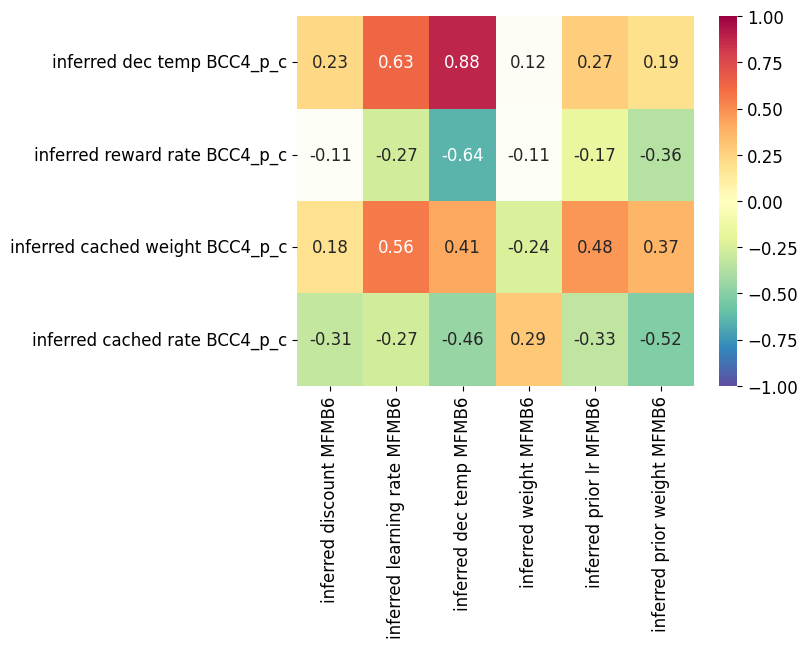

In [35]:
# compare BCC and MFMB6 results

BCC4_p_c_MFMB6_means_df = pd.concat([renamed_BCC4_p_c, renamed_MFMB6], axis='columns')#, join="inner")

print(BCC4_p_c_MFMB6_means_df.keys())

y_vars_of_interest = ["inferred "+name+" MFMB6" for name in MFMB6_param_names]
x_vars_of_interest = ["inferred "+name+" BCC4_p_c" for name in BCC4_p_c_param_names]

print(x_vars_of_interest)
print(y_vars_of_interest)

iu.plot_correlations(BCC4_p_c_MFMB6_means_df, x_vars_of_interest, y_vars_of_interest)

using the BCC6_p_r_c and the MFMB4 model for the comparison

Index(['Unnamed: 0 BCC6_p_r_c', 'inferred dec temp BCC6_p_r_c',
       'subject BCC6_p_r_c', 'inferred reward rate BCC6_p_r_c',
       'inferred habitual tendency BCC6_p_r_c',
       'inferred policy rate BCC6_p_r_c', 'inferred cached weight BCC6_p_r_c',
       'inferred cached rate BCC6_p_r_c', 'Unnamed: 0 MFMB6',
       'inferred discount MFMB6', 'subject MFMB6',
       'inferred learning rate MFMB6', 'inferred dec temp MFMB6',
       'inferred weight MFMB6', 'inferred prior lr MFMB6',
       'inferred prior weight MFMB6'],
      dtype='object')
['inferred dec temp BCC6_p_r_c', 'inferred reward rate BCC6_p_r_c', 'inferred habitual tendency BCC6_p_r_c', 'inferred policy rate BCC6_p_r_c', 'inferred cached weight BCC6_p_r_c', 'inferred cached rate BCC6_p_r_c']
['inferred discount MFMB6', 'inferred learning rate MFMB6', 'inferred dec temp MFMB6', 'inferred weight MFMB6', 'inferred prior lr MFMB6', 'inferred prior weight MFMB6']


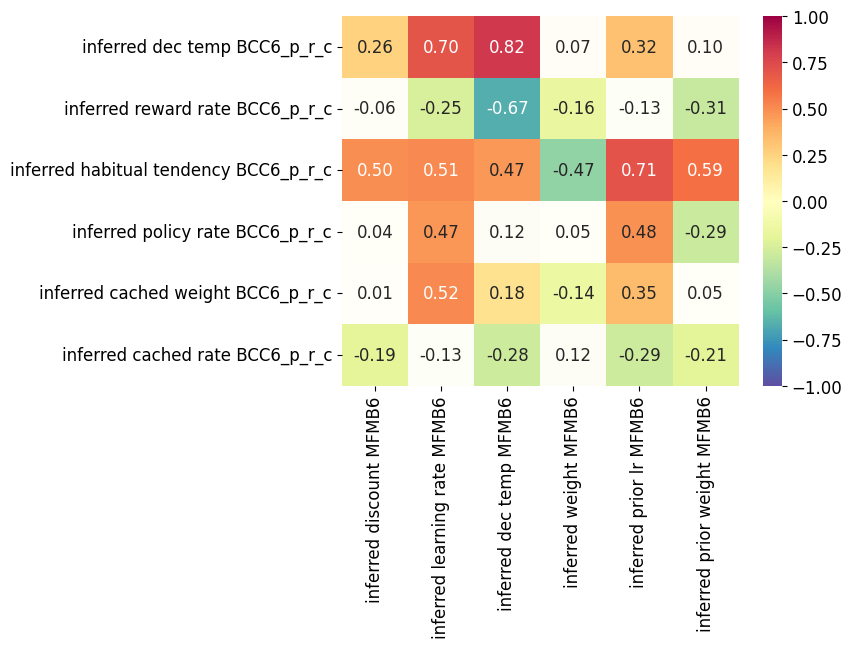

In [36]:
# compare BCC and MFMB6 results

BCC6_p_r_c_MFMB6_means_df = pd.concat([renamed_BCC6_p_r_c, renamed_MFMB6], axis='columns')#, join="inner")

print(BCC6_p_r_c_MFMB6_means_df.keys())

BCC6_p_r_c_param_names = BCC6_p_r_c_agent_params["param_names"]

y_vars_of_interest = ["inferred "+name+" MFMB6" for name in MFMB6_param_names]
x_vars_of_interest = ["inferred "+name+" BCC6_p_r_c" for name in BCC6_p_r_c_param_names]

print(x_vars_of_interest)
print(y_vars_of_interest)

iu.plot_correlations(BCC6_p_r_c_MFMB6_means_df, x_vars_of_interest, y_vars_of_interest)

### Compare inferences between the BCC and MFMB models with transformed parameters

In [37]:
transformed_renamed_MFMB4 = renamed_MFMB4.copy()
transformed_renamed_MFMB4["inferred mb weight MFMB4"] = transformed_renamed_MFMB4["inferred dec temp MFMB4"] * transformed_renamed_MFMB4["inferred weight MFMB4"]
transformed_renamed_MFMB4["inferred mf weight MFMB4"] = transformed_renamed_MFMB4["inferred dec temp MFMB4"] * (1-transformed_renamed_MFMB4["inferred weight MFMB4"])

transformed_renamed_MFMB6 = renamed_MFMB6.copy()
transformed_renamed_MFMB6["inferred mb weight MFMB6"] = transformed_renamed_MFMB6["inferred dec temp MFMB6"] * transformed_renamed_MFMB6["inferred weight MFMB6"]
transformed_renamed_MFMB6["inferred mf weight MFMB6"] = transformed_renamed_MFMB6["inferred dec temp MFMB6"] * (1-transformed_renamed_MFMB6["inferred weight MFMB6"])

using the BCC2_p and the MFMB4 model for the comparison

Index(['Unnamed: 0 BCC2_p', 'inferred dec temp BCC2_p', 'subject BCC2_p',
       'inferred reward rate BCC2_p', 'Unnamed: 0 MFMB4',
       'inferred discount MFMB4', 'subject MFMB4',
       'inferred learning rate MFMB4', 'inferred dec temp MFMB4',
       'inferred weight MFMB4', 'inferred mb weight MFMB4',
       'inferred mf weight MFMB4'],
      dtype='object')


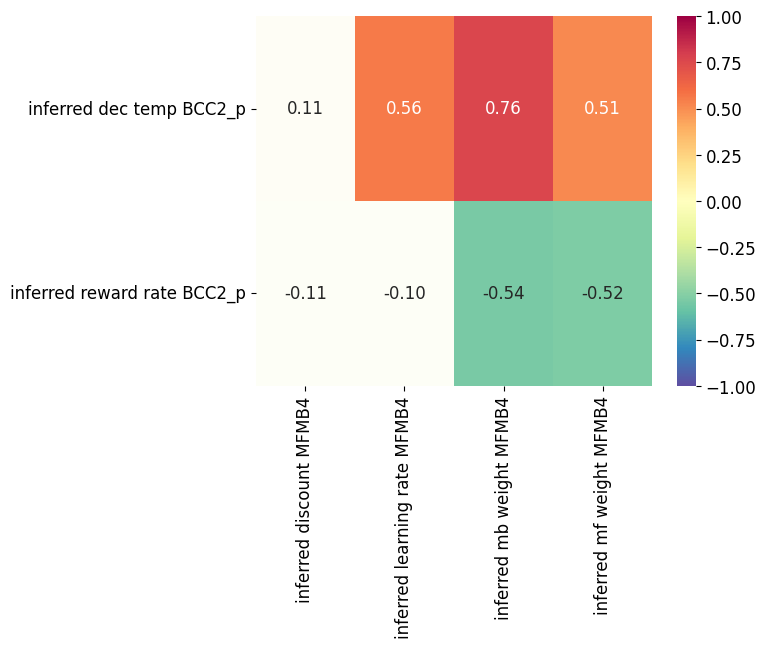

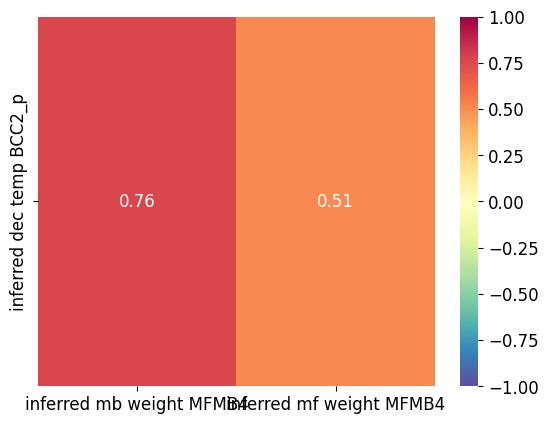

In [38]:
# compare BCC and MBMF4 results

BCC2_p_MBMF4_means_df = pd.concat([renamed_BCC2_p, transformed_renamed_MFMB4], axis='columns')#, join="inner")

print(BCC2_p_MBMF4_means_df.keys())

y_vars_of_interest = ["inferred "+name+" MFMB4" for name in MFMB4_param_names]
y_vars_of_interest.remove("inferred dec temp MFMB4")
y_vars_of_interest.remove("inferred weight MFMB4")
y_vars_of_interest.append("inferred mb weight MFMB4")
y_vars_of_interest.append("inferred mf weight MFMB4")
x_vars_of_interest = ["inferred "+name+" BCC2_p" for name in BCC2_p_param_names]

iu.plot_correlations(BCC2_p_MBMF4_means_df, x_vars_of_interest, y_vars_of_interest)

y_vars_of_interest = ["inferred mb weight MFMB4", "inferred mf weight MFMB4"]
x_vars_of_interest = ["inferred dec temp BCC2_p"]

iu.plot_correlations(BCC2_p_MBMF4_means_df, x_vars_of_interest, y_vars_of_interest)

using the BCC2_p_r and the MFMB4 model for the comparison

Index(['Unnamed: 0 BCC4_p_r', 'inferred dec temp BCC4_p_r', 'subject BCC4_p_r',
       'inferred reward rate BCC4_p_r', 'inferred habitual tendency BCC4_p_r',
       'inferred policy rate BCC4_p_r', 'Unnamed: 0 MFMB4',
       'inferred discount MFMB4', 'subject MFMB4',
       'inferred learning rate MFMB4', 'inferred dec temp MFMB4',
       'inferred weight MFMB4', 'inferred mb weight MFMB4',
       'inferred mf weight MFMB4'],
      dtype='object')


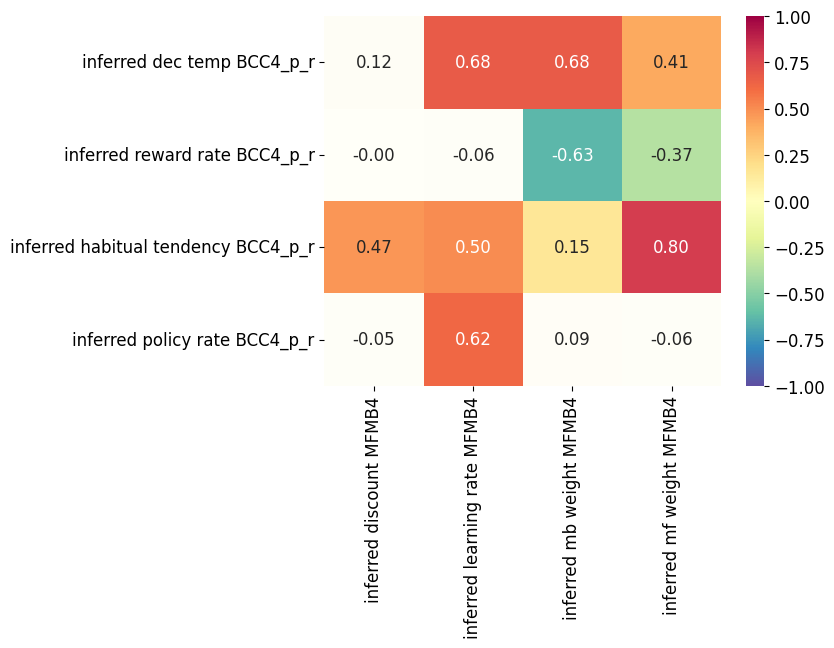

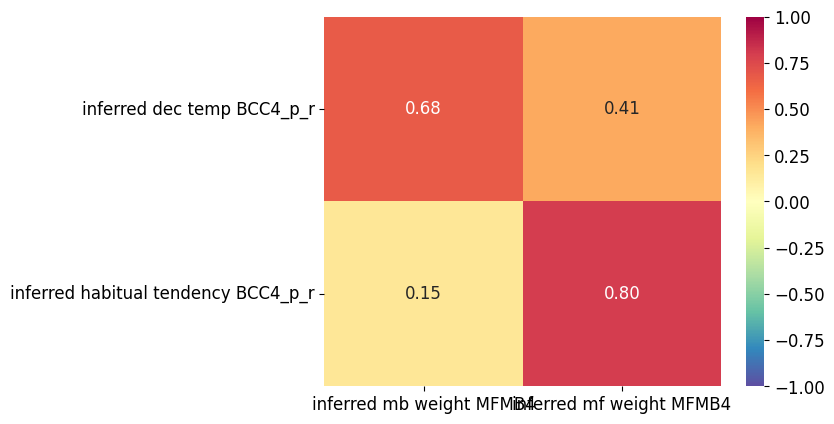

In [39]:
# compare BCC and MBMF4 results

BCC4_p_r_MBMF4_means_df = pd.concat([renamed_BCC4_p_r, transformed_renamed_MFMB4], axis='columns')#, join="inner")

print(BCC4_p_r_MBMF4_means_df.keys())

y_vars_of_interest = ["inferred "+name+" MFMB4" for name in MFMB4_param_names]
y_vars_of_interest.remove("inferred dec temp MFMB4")
y_vars_of_interest.remove("inferred weight MFMB4")
y_vars_of_interest.append("inferred mb weight MFMB4")
y_vars_of_interest.append("inferred mf weight MFMB4")
x_vars_of_interest = ["inferred "+name+" BCC4_p_r" for name in BCC4_p_r_param_names]

iu.plot_correlations(BCC4_p_r_MBMF4_means_df, x_vars_of_interest, y_vars_of_interest)

y_vars_of_interest = ["inferred mb weight MFMB4", "inferred mf weight MFMB4"]
x_vars_of_interest = ["inferred dec temp BCC4_p_r", "inferred habitual tendency BCC4_p_r"]

iu.plot_correlations(BCC4_p_r_MBMF4_means_df, x_vars_of_interest, y_vars_of_interest)

using the BCC2_p_c and the MFMB4 model for the comparison

Index(['Unnamed: 0 BCC4_p_c', 'inferred dec temp BCC4_p_c', 'subject BCC4_p_c',
       'inferred reward rate BCC4_p_c', 'inferred cached weight BCC4_p_c',
       'inferred cached rate BCC4_p_c', 'Unnamed: 0 MFMB4',
       'inferred discount MFMB4', 'subject MFMB4',
       'inferred learning rate MFMB4', 'inferred dec temp MFMB4',
       'inferred weight MFMB4', 'inferred mb weight MFMB4',
       'inferred mf weight MFMB4'],
      dtype='object')


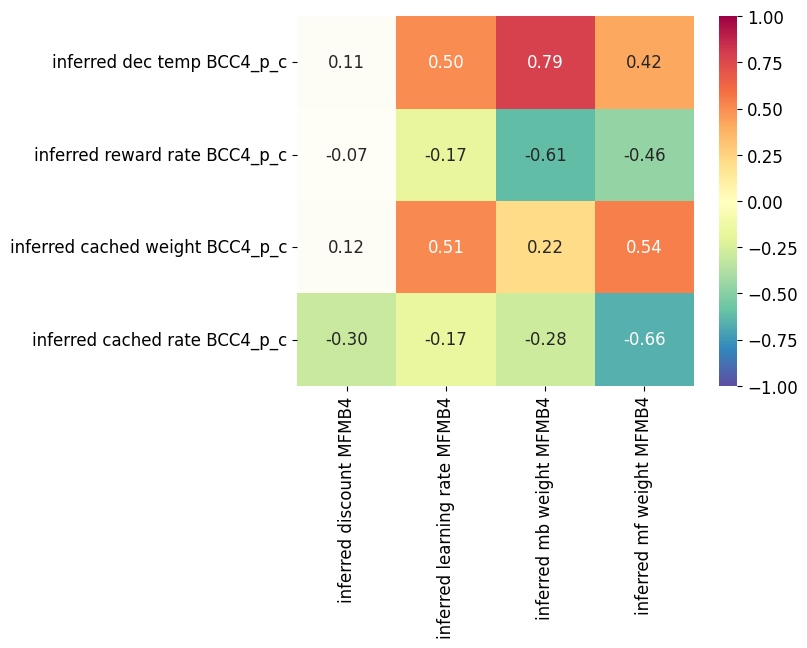

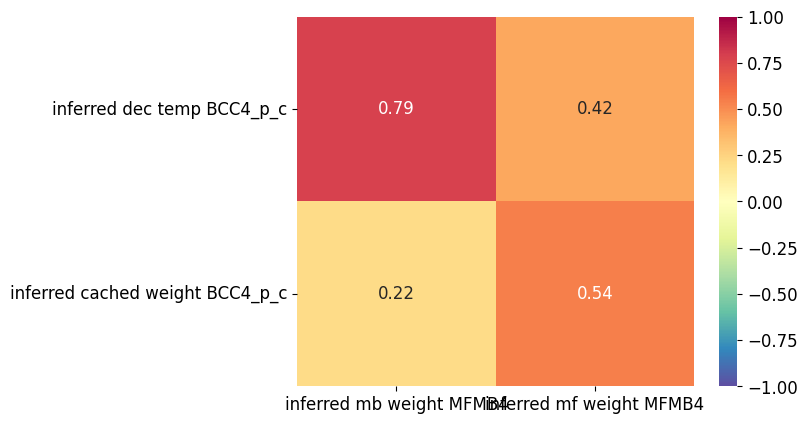

In [40]:
# compare BCC and MBMF4 results

BCC4_p_c_MBMF4_means_df = pd.concat([renamed_BCC4_p_c, transformed_renamed_MFMB4], axis='columns')#, join="inner")

print(BCC4_p_c_MBMF4_means_df.keys())

y_vars_of_interest = ["inferred "+name+" MFMB4" for name in MFMB4_param_names]
y_vars_of_interest.remove("inferred dec temp MFMB4")
y_vars_of_interest.remove("inferred weight MFMB4")
y_vars_of_interest.append("inferred mb weight MFMB4")
y_vars_of_interest.append("inferred mf weight MFMB4")
x_vars_of_interest = ["inferred "+name+" BCC4_p_c" for name in BCC4_p_c_param_names]

iu.plot_correlations(BCC4_p_c_MBMF4_means_df, x_vars_of_interest, y_vars_of_interest)

y_vars_of_interest = ["inferred mb weight MFMB4", "inferred mf weight MFMB4"]
x_vars_of_interest = ["inferred dec temp BCC4_p_c", "inferred cached weight BCC4_p_c"]

iu.plot_correlations(BCC4_p_c_MBMF4_means_df, x_vars_of_interest, y_vars_of_interest)

using the BCC6_p_r_c and the MFMB4 model for the comparison

Index(['Unnamed: 0 BCC6_p_r_c', 'inferred dec temp BCC6_p_r_c',
       'subject BCC6_p_r_c', 'inferred reward rate BCC6_p_r_c',
       'inferred habitual tendency BCC6_p_r_c',
       'inferred policy rate BCC6_p_r_c', 'inferred cached weight BCC6_p_r_c',
       'inferred cached rate BCC6_p_r_c', 'Unnamed: 0 MFMB4',
       'inferred discount MFMB4', 'subject MFMB4',
       'inferred learning rate MFMB4', 'inferred dec temp MFMB4',
       'inferred weight MFMB4', 'inferred mb weight MFMB4',
       'inferred mf weight MFMB4'],
      dtype='object')


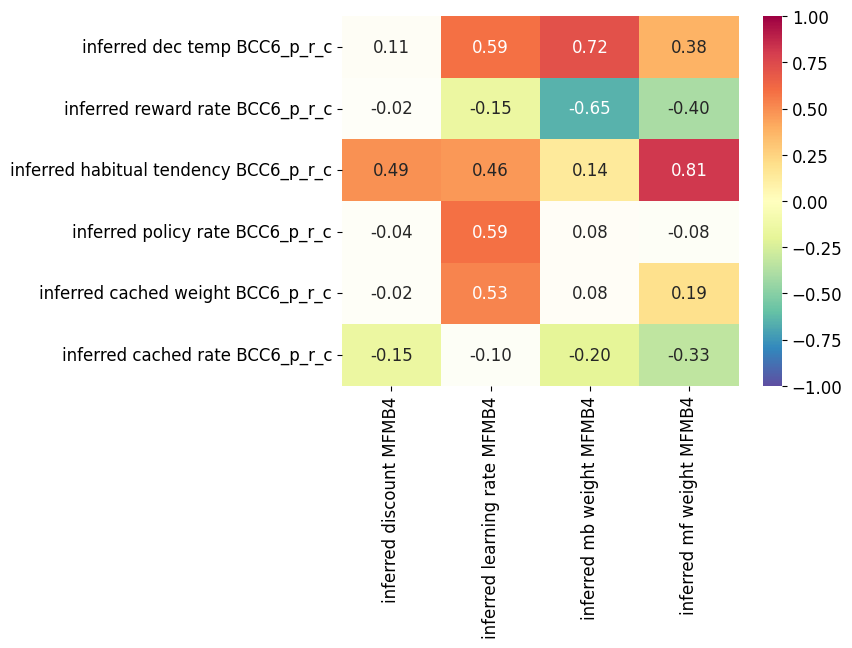

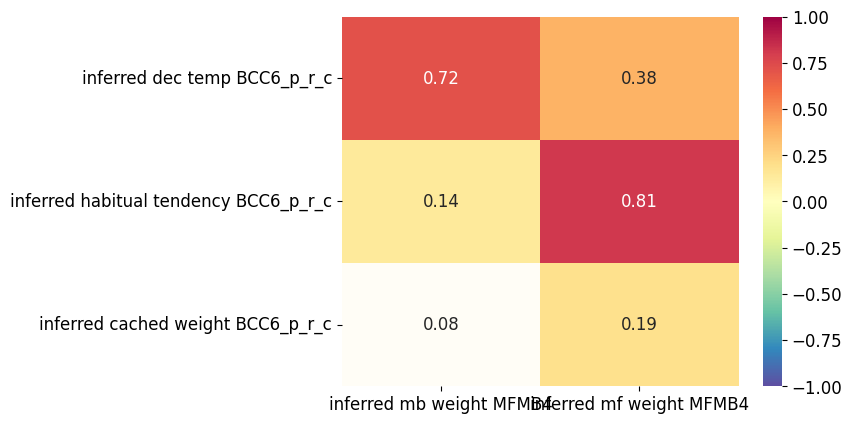

In [41]:
# compare BCC and MBMF4 results

BCC6_p_r_c_MBMF4_means_df = pd.concat([renamed_BCC6_p_r_c, transformed_renamed_MFMB4], axis='columns')#, join="inner")

print(BCC6_p_r_c_MBMF4_means_df.keys())

BCC6_p_r_c_param_names = BCC6_p_r_c_agent_params["param_names"]

y_vars_of_interest = ["inferred "+name+" MFMB4" for name in MFMB4_param_names]
y_vars_of_interest.remove("inferred dec temp MFMB4")
y_vars_of_interest.remove("inferred weight MFMB4")
y_vars_of_interest.append("inferred mb weight MFMB4")
y_vars_of_interest.append("inferred mf weight MFMB4")
x_vars_of_interest = ["inferred "+name+" BCC6_p_r_c" for name in BCC6_p_r_c_param_names]

iu.plot_correlations(BCC6_p_r_c_MBMF4_means_df, x_vars_of_interest, y_vars_of_interest)

y_vars_of_interest = ["inferred mb weight MFMB4", "inferred mf weight MFMB4"]
x_vars_of_interest = ["inferred dec temp BCC6_p_r_c", "inferred habitual tendency BCC6_p_r_c", "inferred cached weight BCC6_p_r_c"]

iu.plot_correlations(BCC6_p_r_c_MBMF4_means_df, x_vars_of_interest, y_vars_of_interest)

using the BCC2_p and the MFMB6 model for the comparison

Index(['Unnamed: 0 BCC2_p', 'inferred dec temp BCC2_p', 'subject BCC2_p',
       'inferred reward rate BCC2_p', 'Unnamed: 0 MFMB6',
       'inferred discount MFMB6', 'subject MFMB6',
       'inferred learning rate MFMB6', 'inferred dec temp MFMB6',
       'inferred weight MFMB6', 'inferred prior lr MFMB6',
       'inferred prior weight MFMB6', 'inferred mb weight MFMB6',
       'inferred mf weight MFMB6'],
      dtype='object')


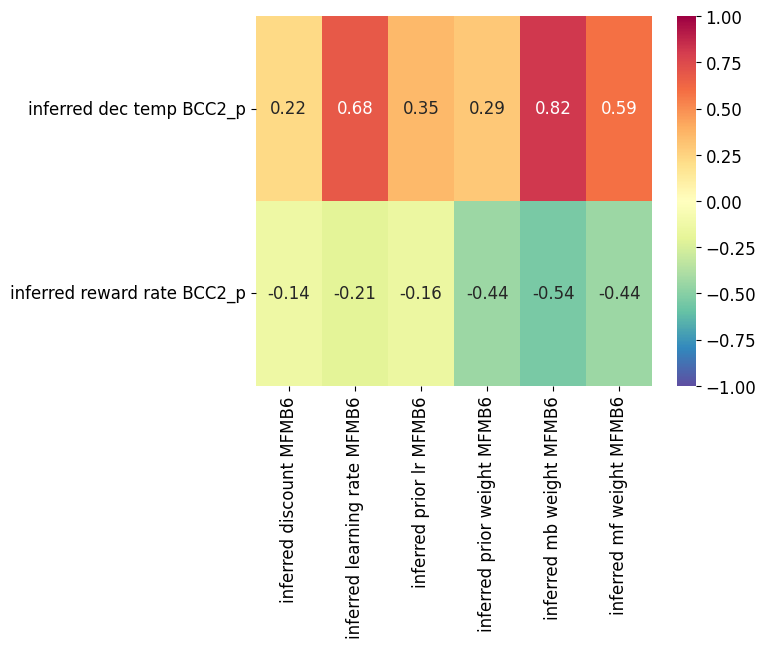

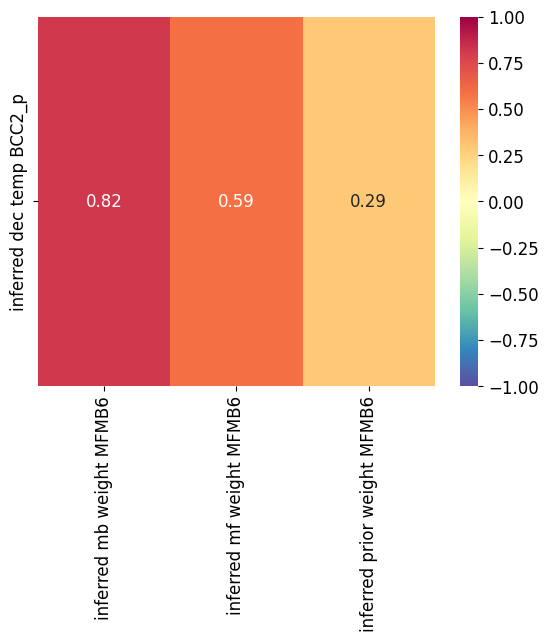

In [42]:
# compare BCC and MFMB6 results

BCC2_p_MFMB6_means_df = pd.concat([renamed_BCC2_p, transformed_renamed_MFMB6], axis='columns')#, join="inner")

print(BCC2_p_MFMB6_means_df.keys())

MFMB6_param_names = MFMB6_mf_mb_prior_agent_params["param_names"]

y_vars_of_interest = ["inferred "+name+" MFMB6" for name in MFMB6_param_names]
y_vars_of_interest.remove("inferred dec temp MFMB6")
y_vars_of_interest.remove("inferred weight MFMB6")
y_vars_of_interest.append("inferred mb weight MFMB6")
y_vars_of_interest.append("inferred mf weight MFMB6")
x_vars_of_interest = ["inferred "+name+" BCC2_p" for name in BCC2_p_param_names]

iu.plot_correlations(BCC2_p_MFMB6_means_df, x_vars_of_interest, y_vars_of_interest)

y_vars_of_interest = ["inferred mb weight MFMB6", "inferred mf weight MFMB6", "inferred prior weight MFMB6"]
x_vars_of_interest = ["inferred dec temp BCC2_p"]

iu.plot_correlations(BCC2_p_MFMB6_means_df, x_vars_of_interest, y_vars_of_interest)

using the BCC2_p_r and the MFMB6 model for the comparison

Index(['Unnamed: 0 BCC4_p_r', 'inferred dec temp BCC4_p_r', 'subject BCC4_p_r',
       'inferred reward rate BCC4_p_r', 'inferred habitual tendency BCC4_p_r',
       'inferred policy rate BCC4_p_r', 'Unnamed: 0 MFMB6',
       'inferred discount MFMB6', 'subject MFMB6',
       'inferred learning rate MFMB6', 'inferred dec temp MFMB6',
       'inferred weight MFMB6', 'inferred prior lr MFMB6',
       'inferred prior weight MFMB6', 'inferred mb weight MFMB6',
       'inferred mf weight MFMB6'],
      dtype='object')


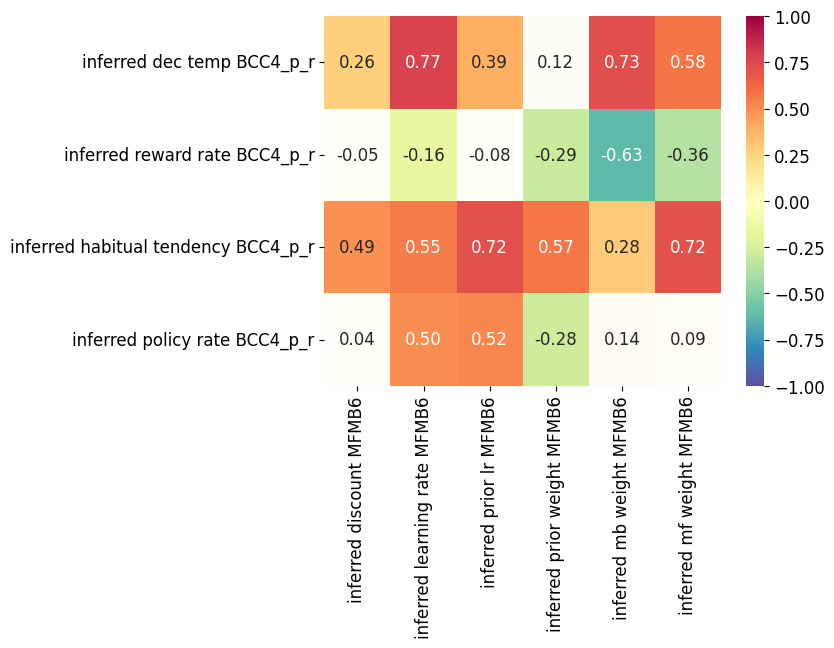

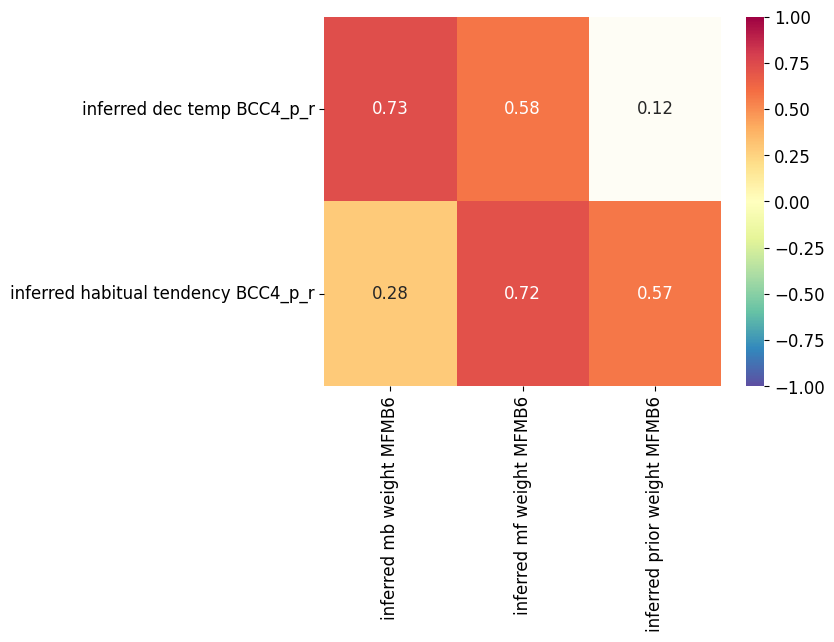

In [43]:
# compare BCC and MFMB6 results

BCC4_p_r_MFMB6_means_df = pd.concat([renamed_BCC4_p_r, transformed_renamed_MFMB6], axis='columns')#, join="inner")

print(BCC4_p_r_MFMB6_means_df.keys())

y_vars_of_interest = ["inferred "+name+" MFMB6" for name in MFMB6_param_names]
y_vars_of_interest.remove("inferred dec temp MFMB6")
y_vars_of_interest.remove("inferred weight MFMB6")
y_vars_of_interest.append("inferred mb weight MFMB6")
y_vars_of_interest.append("inferred mf weight MFMB6")
x_vars_of_interest = ["inferred "+name+" BCC4_p_r" for name in BCC4_p_r_param_names]

iu.plot_correlations(BCC4_p_r_MFMB6_means_df, x_vars_of_interest, y_vars_of_interest)

y_vars_of_interest = ["inferred mb weight MFMB6", "inferred mf weight MFMB6", "inferred prior weight MFMB6"]
x_vars_of_interest = ["inferred dec temp BCC4_p_r", "inferred habitual tendency BCC4_p_r"]

iu.plot_correlations(BCC4_p_r_MFMB6_means_df, x_vars_of_interest, y_vars_of_interest)

using the BCC2_p_c and the MFMB6 model for the comparison

Index(['Unnamed: 0 BCC4_p_c', 'inferred dec temp BCC4_p_c', 'subject BCC4_p_c',
       'inferred reward rate BCC4_p_c', 'inferred cached weight BCC4_p_c',
       'inferred cached rate BCC4_p_c', 'Unnamed: 0 MFMB6',
       'inferred discount MFMB6', 'subject MFMB6',
       'inferred learning rate MFMB6', 'inferred dec temp MFMB6',
       'inferred weight MFMB6', 'inferred prior lr MFMB6',
       'inferred prior weight MFMB6', 'inferred mb weight MFMB6',
       'inferred mf weight MFMB6'],
      dtype='object')


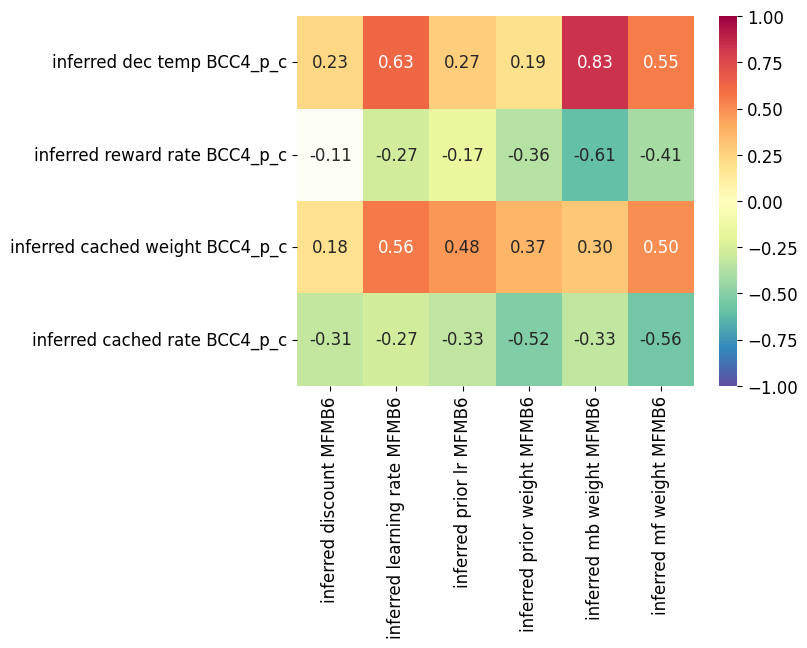

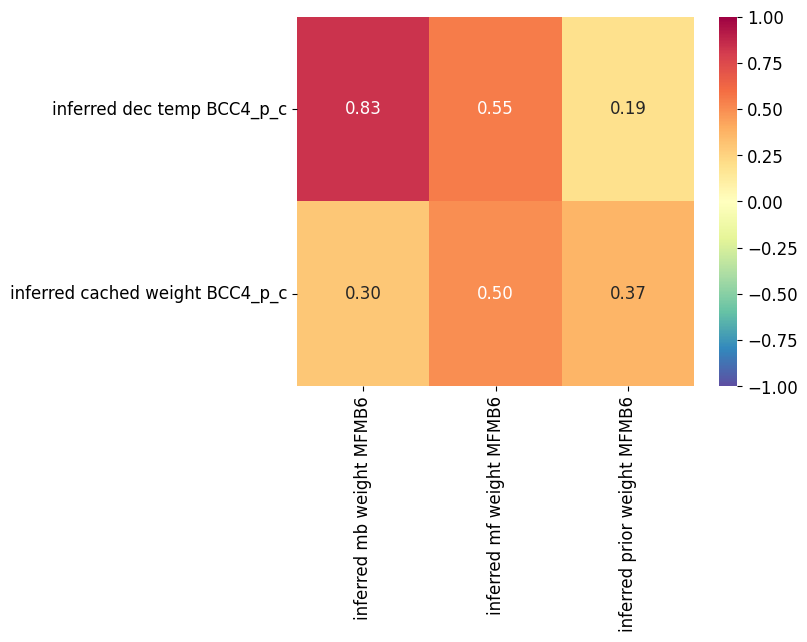

In [44]:
# compare BCC and MFMB6 results

BCC4_p_c_MFMB6_means_df = pd.concat([renamed_BCC4_p_c, transformed_renamed_MFMB6], axis='columns')#, join="inner")

print(BCC4_p_c_MFMB6_means_df.keys())

y_vars_of_interest = ["inferred "+name+" MFMB6" for name in MFMB6_param_names]
y_vars_of_interest.remove("inferred dec temp MFMB6")
y_vars_of_interest.remove("inferred weight MFMB6")
y_vars_of_interest.append("inferred mb weight MFMB6")
y_vars_of_interest.append("inferred mf weight MFMB6")
x_vars_of_interest = ["inferred "+name+" BCC4_p_c" for name in BCC4_p_c_param_names]

iu.plot_correlations(BCC4_p_c_MFMB6_means_df, x_vars_of_interest, y_vars_of_interest)

y_vars_of_interest = ["inferred mb weight MFMB6", "inferred mf weight MFMB6", "inferred prior weight MFMB6"]
x_vars_of_interest = ["inferred dec temp BCC4_p_c", "inferred cached weight BCC4_p_c"]

iu.plot_correlations(BCC4_p_c_MFMB6_means_df, x_vars_of_interest, y_vars_of_interest)

using the BCC6_p_r_c and the MFMB4 model for the comparison

Index(['Unnamed: 0 BCC6_p_r_c', 'inferred dec temp BCC6_p_r_c',
       'subject BCC6_p_r_c', 'inferred reward rate BCC6_p_r_c',
       'inferred habitual tendency BCC6_p_r_c',
       'inferred policy rate BCC6_p_r_c', 'inferred cached weight BCC6_p_r_c',
       'inferred cached rate BCC6_p_r_c', 'Unnamed: 0 MFMB6',
       'inferred discount MFMB6', 'subject MFMB6',
       'inferred learning rate MFMB6', 'inferred dec temp MFMB6',
       'inferred weight MFMB6', 'inferred prior lr MFMB6',
       'inferred prior weight MFMB6', 'inferred mb weight MFMB6',
       'inferred mf weight MFMB6'],
      dtype='object')


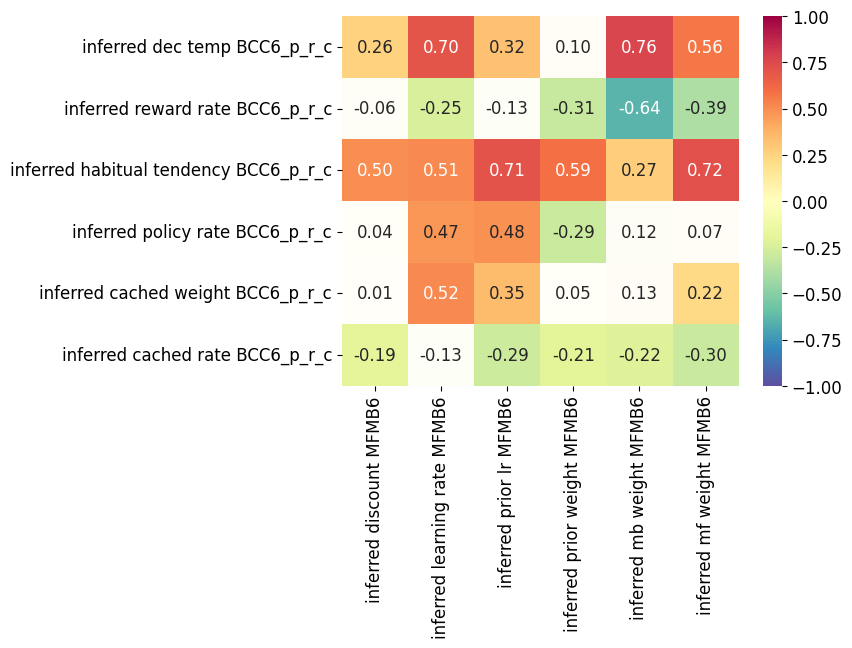

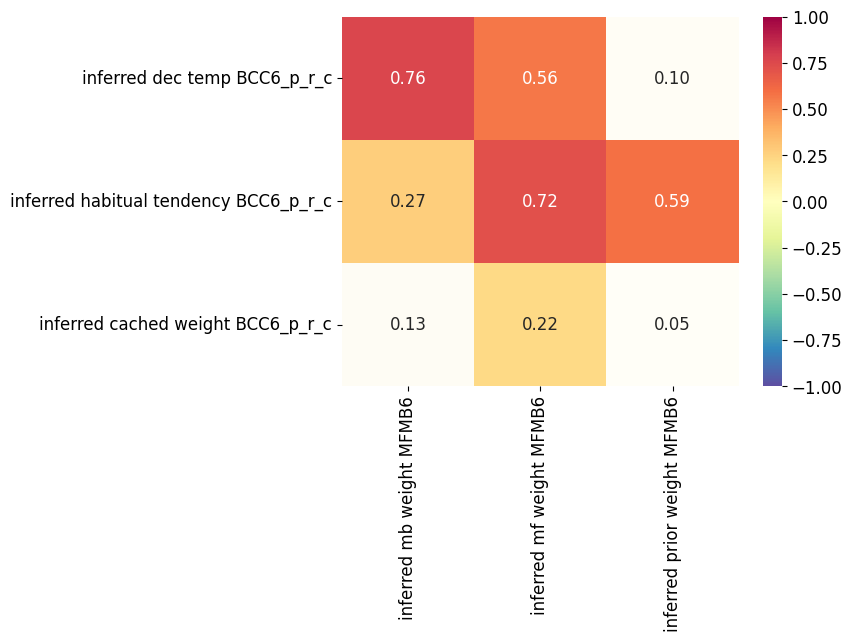

In [45]:
# compare BCC and MFMB6 results

BCC6_p_r_c_MFMB6_means_df = pd.concat([renamed_BCC6_p_r_c, transformed_renamed_MFMB6], axis='columns')#, join="inner")

print(BCC6_p_r_c_MFMB6_means_df.keys())

BCC6_p_r_c_param_names = BCC6_p_r_c_agent_params["param_names"]

y_vars_of_interest = ["inferred "+name+" MFMB6" for name in MFMB6_param_names]
y_vars_of_interest.remove("inferred dec temp MFMB6")
y_vars_of_interest.remove("inferred weight MFMB6")
y_vars_of_interest.append("inferred mb weight MFMB6")
y_vars_of_interest.append("inferred mf weight MFMB6")
x_vars_of_interest = ["inferred "+name+" BCC6_p_r_c" for name in BCC6_p_r_c_param_names]

iu.plot_correlations(BCC6_p_r_c_MFMB6_means_df, x_vars_of_interest, y_vars_of_interest)

y_vars_of_interest = ["inferred mb weight MFMB6", "inferred mf weight MFMB6", "inferred prior weight MFMB6"]
x_vars_of_interest = ["inferred dec temp BCC6_p_r_c", "inferred habitual tendency BCC6_p_r_c", "inferred cached weight BCC6_p_r_c"]

iu.plot_correlations(BCC6_p_r_c_MFMB6_means_df, x_vars_of_interest, y_vars_of_interest)